# Building and Using an SMA Backtester Class

This notebook shows how to build a reusable object-oriented workflow for an SMA crossover strategy. Instead of rewriting the same backtest logic again and again, we will create a `SMABacktester` class that can load data, prepare signals, backtest performance, plot results, change parameters, optimise parameter combinations, and compare in-sample and out-of-sample behaviour.

> **Disclaimer**
>
> This notebook is for educational purposes only. It is **not** financial advice. The examples are simplified and do not include important real-world considerations such as transaction costs, spreads, slippage, position sizing, risk controls, and forward testing. Real trading requires much more validation than a simple historical backtest.


## 1. Import Libraries

We use `pandas` and `numpy` for data handling, `matplotlib` for charts, `itertools.product` for parameter search, and `Path` for file handling.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from pathlib import Path

pd.options.display.float_format = '{:,.6f}'.format
plt.style.use('default')


## 2. Load or Generate Data

The notebook first looks for `forex_pairs.csv`. If the file is missing, it creates a synthetic example dataset with three FX-style instruments, adds a few missing values, saves the file, and then loads it back in the same way we would load a real dataset.


             EURUSD   AUDEUR   USDGBP
Date                                 
2004-01-01 1.201671 0.650033 0.549273
2004-01-02 1.196084 0.650040 0.547288
2004-01-05 1.200154 0.650722 0.551852
2004-01-06 1.205269 0.656196 0.550792
2004-01-07 1.194757 0.657086 0.549739

             EURUSD   AUDEUR   USDGBP
Date                                 
2020-06-24 1.003797 0.702872 0.352622
2020-06-25 1.001816 0.706153 0.351671
2020-06-26 1.006790 0.703052 0.350448
2020-06-29 1.003543 0.708153 0.349072
2020-06-30 1.000881 0.704376 0.348741

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4304 entries, 2004-01-01 to 2020-06-30
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EURUSD  4294 non-null   float64
 1   AUDEUR  4294 non-null   float64
 2   USDGBP  4294 non-null   float64
dtypes: float64(3)
memory usage: 134.5 KB


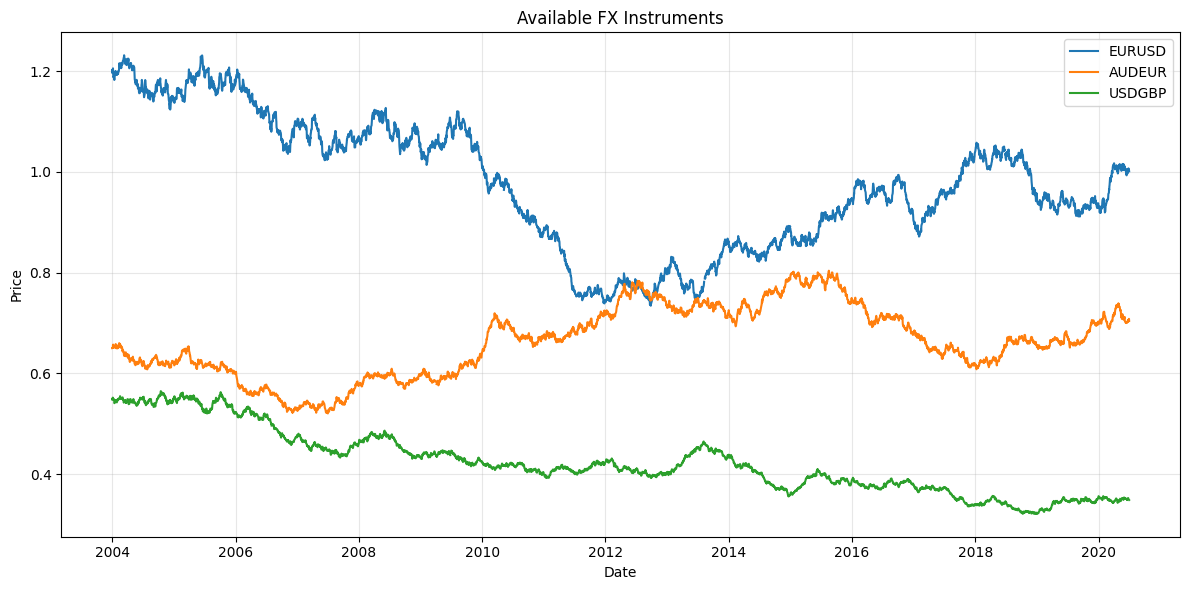

In [3]:
data_path = Path("forex_pairs.csv")

if not data_path.exists():
    rng = np.random.default_rng(42)
    dates = pd.date_range("2004-01-01", "2020-06-30", freq="B")
    n = len(dates)

    def make_fx_series(start_level, drift, vol):
        log_returns = rng.normal(loc=drift, scale=vol, size=n)
        return start_level * np.exp(np.cumsum(log_returns))

    synthetic = pd.DataFrame({
        "Date": dates,
        "EURUSD": make_fx_series(1.20, 0.00002, 0.0045),
        "AUDEUR": make_fx_series(0.65, 0.00001, 0.0040),
        "USDGBP": make_fx_series(0.55, -0.00001, 0.0038),
    })

    # Add a few missing values to imitate real-world data issues.
    for column in ["EURUSD", "AUDEUR", "USDGBP"]:
        missing_idx = rng.choice(n, size=10, replace=False)
        synthetic.loc[missing_idx, column] = np.nan

    synthetic.to_csv(data_path, index=False)
    print("Created synthetic forex_pairs.csv")

df = pd.read_csv(data_path, parse_dates=["Date"])
df = df.set_index("Date").sort_index()

print(df.head())
print()
print(df.tail())
print()
df.info()

plt.figure(figsize=(12, 6))
for column in df.columns:
    plt.plot(df.index, df[column], label=column)
plt.title("Available FX Instruments")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Create the `SMABacktester` Class

This class wraps the full workflow: loading one instrument, preparing returns and moving averages, building a trading signal, backtesting the strategy, plotting results, changing parameters, and optimising over many SMA combinations.


In [4]:
class SMABacktester:
    def __init__(self, symbol, sma_short, sma_long, start, end, data_path="forex_pairs.csv"):
        self.symbol = symbol
        self.sma_short = sma_short
        self.sma_long = sma_long
        self.start = start
        self.end = end
        self.data_path = Path(data_path)
        self.data = None
        self.results = None
        self.optimization_results = None
        self.get_data()
        self.prepare_data()

    def __repr__(self):
        return (
            f"SMABacktester(symbol={self.symbol}, SMA_Short={self.sma_short}, "
            f"SMA_Long={self.sma_long}, start={self.start}, end={self.end})"
        )

    def get_data(self):
        data = pd.read_csv(self.data_path, parse_dates=["Date"])
        data = data.set_index("Date").sort_index()

        if self.symbol not in data.columns:
            raise ValueError(f"Symbol {self.symbol} not found in {self.data_path}.")

        data = data[[self.symbol]].rename(columns={self.symbol: "price"})
        data = data.loc[self.start:self.end].copy()
        data = data.dropna().copy()
        data["returns"] = np.log(data["price"] / data["price"].shift(1))
        self.data = data.dropna().copy()

    def prepare_data(self):
        data = self.data.copy()
        data["SMA_Short"] = data["price"].rolling(self.sma_short).mean()
        data["SMA_Long"] = data["price"].rolling(self.sma_long).mean()
        data = data.dropna().copy()
        data["position"] = np.where(data["SMA_Short"] > data["SMA_Long"], 1, -1)
        data["strategy"] = data["position"].shift(1) * data["returns"]
        data = data.dropna().copy()
        data["cret"] = np.exp(data["returns"].cumsum())
        data["cstrategy"] = np.exp(data["strategy"].cumsum())
        self.results = data

    def set_parameters(self, sma_short=None, sma_long=None):
        if sma_short is not None:
            self.sma_short = sma_short
        if sma_long is not None:
            self.sma_long = sma_long
        self.prepare_data()

    def test_strategy(self):
        strategy_perf = self.results["cstrategy"].iloc[-1]
        bh_perf = self.results["cret"].iloc[-1]
        outperformance = strategy_perf - bh_perf

        strategy_perf = round(float(strategy_perf), 6)
        bh_perf = round(float(bh_perf), 6)
        outperformance = round(float(outperformance), 6)

        print(f"Strategy Performance: {strategy_perf}")
        print(f"Buy and Hold Performance: {bh_perf}")
        print(f"Outperformance: {outperformance}")
        return strategy_perf, outperformance

    def plot_results(self):
        plt.figure(figsize=(12, 6))
        plt.plot(self.results.index, self.results["cret"], label="Buy and Hold")
        plt.plot(self.results.index, self.results["cstrategy"], label="SMA Strategy")
        plt.title(f"{self.symbol} | SMA {self.sma_short}/{self.sma_long}")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Growth")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    def optimize_parameters(self, sma_short_range, sma_long_range):
        short_values = range(*sma_short_range)
        long_values = range(*sma_long_range)
        results = []

        for sma_short, sma_long in product(short_values, long_values):
            if sma_short < sma_long:
                self.set_parameters(sma_short=sma_short, sma_long=sma_long)
                performance = float(self.results["cstrategy"].iloc[-1])
                outperformance = float(self.results["cstrategy"].iloc[-1] - self.results["cret"].iloc[-1])
                results.append((sma_short, sma_long, performance, outperformance))

        self.optimization_results = pd.DataFrame(
            results,
            columns=["SMA_Short", "SMA_Long", "Performance", "Outperformance"]
        ).sort_values("Performance", ascending=False).reset_index(drop=True)

        best_row = self.optimization_results.iloc[0]
        best_short = int(best_row["SMA_Short"])
        best_long = int(best_row["SMA_Long"])
        best_performance = round(float(best_row["Performance"]), 6)

        self.set_parameters(sma_short=best_short, sma_long=best_long)
        return (best_short, best_long), best_performance


## 4. Demonstrate the Class

We start with a standard EUR/USD tester using SMA 50 and SMA 200, then inspect the object, preview the prepared results, run the backtest, and plot cumulative performance.


In [5]:
tester = SMABacktester(
    symbol="EURUSD",
    sma_short=50,
    sma_long=200,
    start="2004-01-01",
    end="2020-06-30"
)

print(tester)
tester.results.head()


SMABacktester(symbol=EURUSD, SMA_Short=50, SMA_Long=200, start=2004-01-01, end=2020-06-30)


,price,returns,SMA_Short,SMA_Long,position,strategy,cret,cstrategy
Date,,,,,,,,
2004-10-08,1.181528,0.006354,1.159370,1.184342,-1,-0.006354,1.006374,0.993666
2004-10-11,1.182034,0.000428,1.160044,1.184252,-1,-0.000428,1.006804,0.993242
2004-10-12,1.185487,0.002918,1.160836,1.184153,-1,-0.002918,1.009746,0.990348
2004-10-13,1.174624,-0.009206,1.161417,1.184052,-1,0.009206,1.000493,0.999507
2004-10-14,1.174390,-0.000199,1.161809,1.183985,-1,0.000199,1.000294,0.999706


Strategy Performance: 0.947053
Buy and Hold Performance: 0.852506
Outperformance: 0.094547


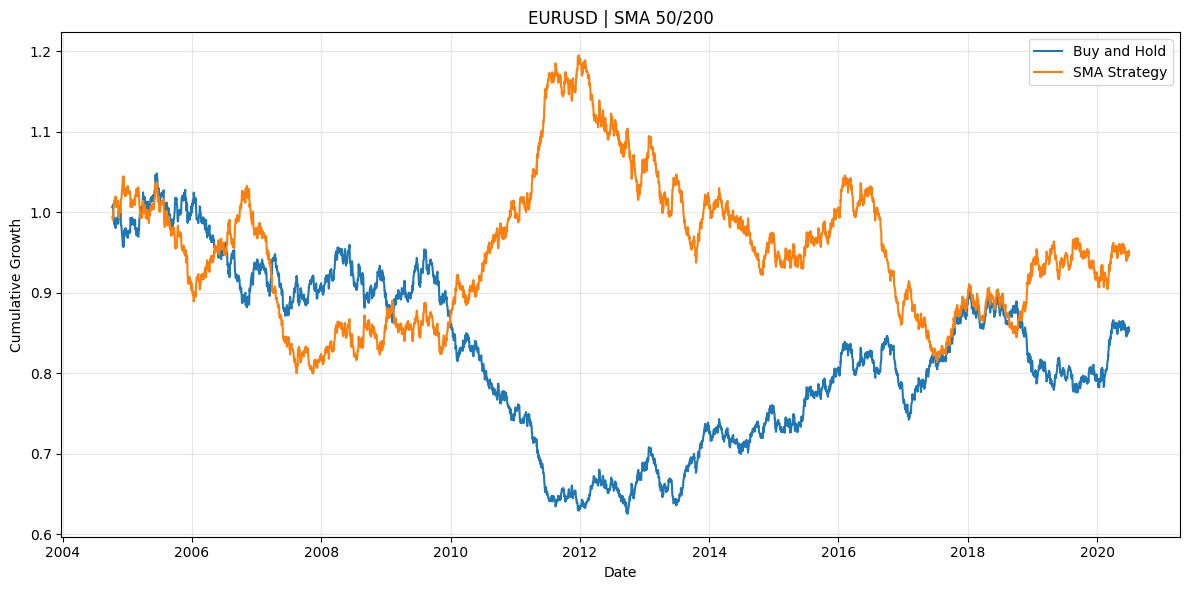

In [6]:
tester.test_strategy()
tester.plot_results()


## 5. Change Strategy Parameters

A main benefit of the class structure is that we can retest a different SMA combination quickly without rewriting the strategy code.


Strategy Performance: 1.011232
Buy and Hold Performance: 0.861053
Outperformance: 0.15018


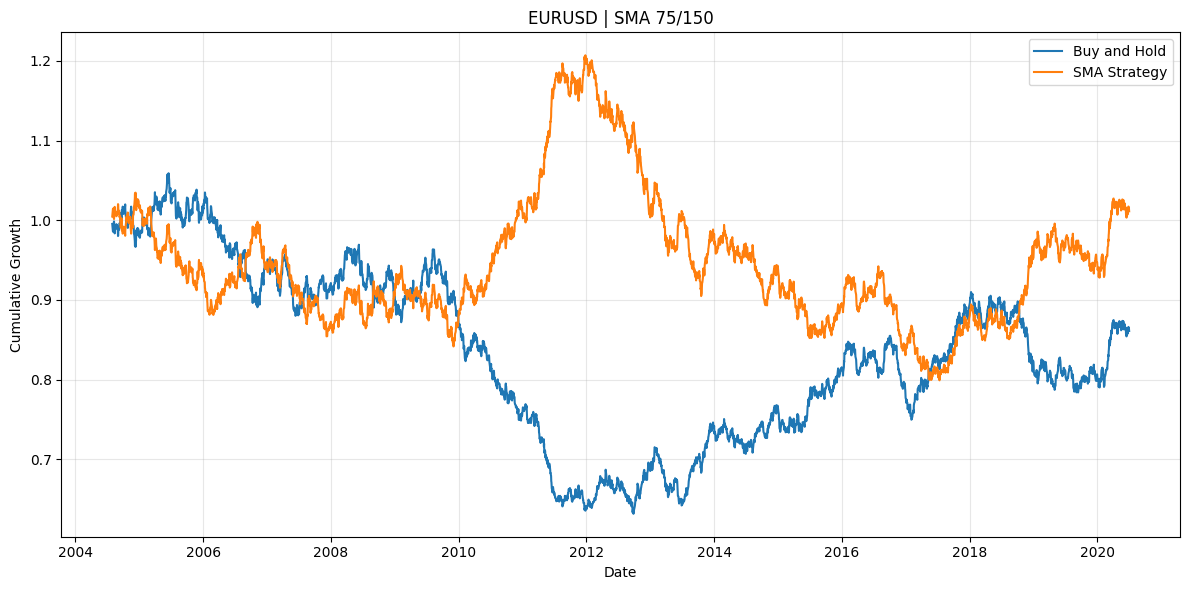

In [7]:
tester.set_parameters(sma_short=75, sma_long=150)
tester.test_strategy()
tester.plot_results()


## 6. Optimise SMA Parameters

We now search across many SMA combinations to find the best historical result for this sample. This is an in-sample optimization, so it can easily lead to overfitting.


Best parameters: (37, 100)
Best performance: 1.400144

Top 10 parameter combinations:
   SMA_Short  SMA_Long  Performance  Outperformance
0         37       100     1.400144        0.547265
1         35       100     1.395200        0.542322
2         36       101     1.381508        0.533618
3         36       102     1.376026        0.526793
4         37       101     1.365913        0.518023
5         34       100     1.351312        0.498434
6         36       100     1.348844        0.495965
7         35       103     1.327153        0.480751
8         35       101     1.323671        0.475781
9         34       101     1.307919        0.460029


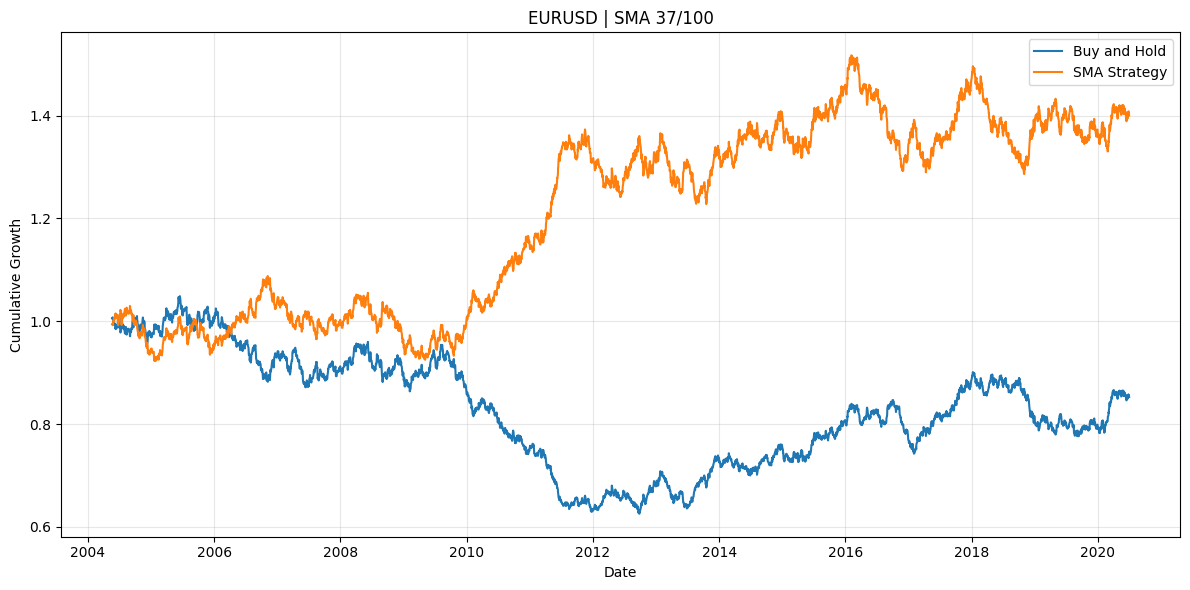

In [8]:
best_params, best_perf = tester.optimize_parameters(
    sma_short_range=(25, 50, 1),
    sma_long_range=(100, 200, 1)
)

print("Best parameters:", best_params)
print("Best performance:", best_perf)
print()
print("Top 10 parameter combinations:")
print(tester.optimization_results.head(10))

tester.plot_results()


## 7. Visualise the Optimization Surface

A heatmap helps us see whether performance is concentrated in a small region or whether a wider area of SMA combinations behaves similarly.


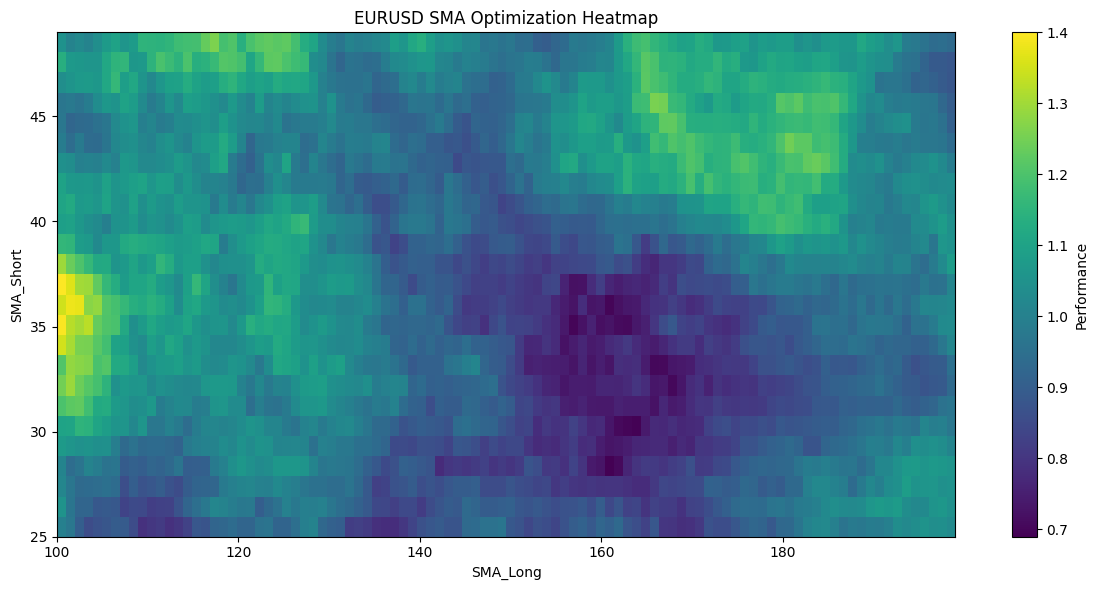

In [9]:
pivot = tester.optimization_results.pivot(index="SMA_Short", columns="SMA_Long", values="Performance")

plt.figure(figsize=(12, 6))
image = plt.imshow(
    pivot,
    aspect="auto",
    origin="lower",
    extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()]
)
plt.colorbar(image, label="Performance")
plt.title("EURUSD SMA Optimization Heatmap")
plt.xlabel("SMA_Long")
plt.ylabel("SMA_Short")
plt.tight_layout()
plt.show()


## 8. In-Sample / Out-of-Sample Test

Next, we fit the strategy on a training period and then test the selected parameters on unseen data. This is a much healthier workflow than optimising and judging everything on the same sample.


Training best parameters: (36, 101)
Training best performance: 1.465946


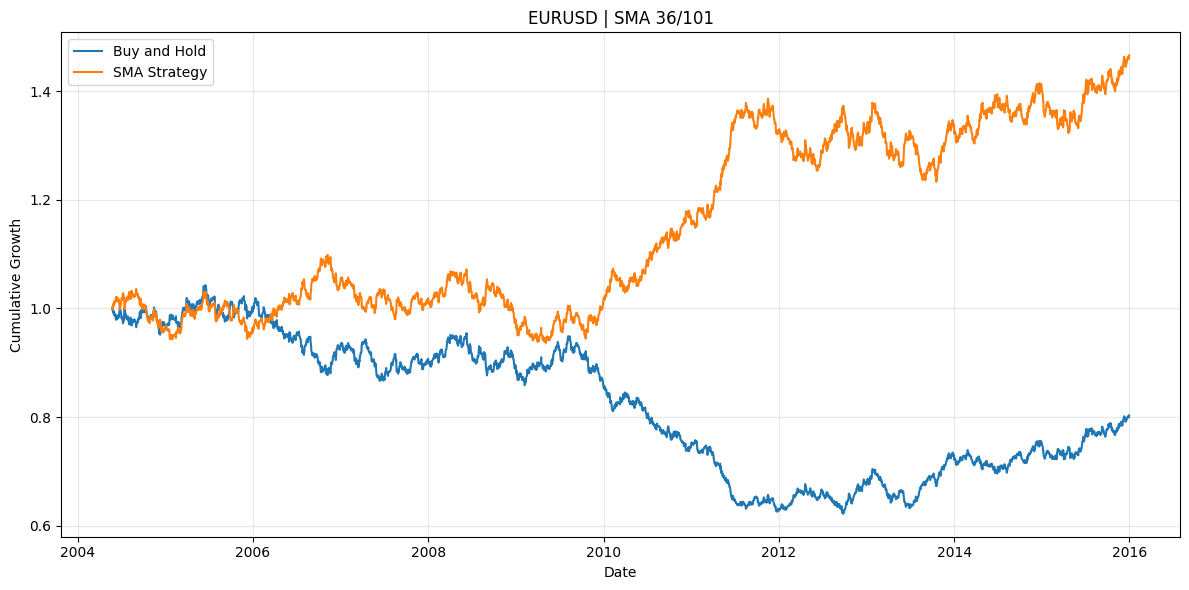

In [10]:
train_tester = SMABacktester("EURUSD", 50, 200, "2004-01-01", "2015-12-31")
train_best_params, train_best_perf = train_tester.optimize_parameters((25, 50, 1), (100, 200, 1))
print("Training best parameters:", train_best_params)
print("Training best performance:", train_best_perf)
train_tester.plot_results()

best_sma_short, best_sma_long = train_best_params


Strategy Performance: 0.944148
Buy and Hold Performance: 1.051186
Outperformance: -0.107038


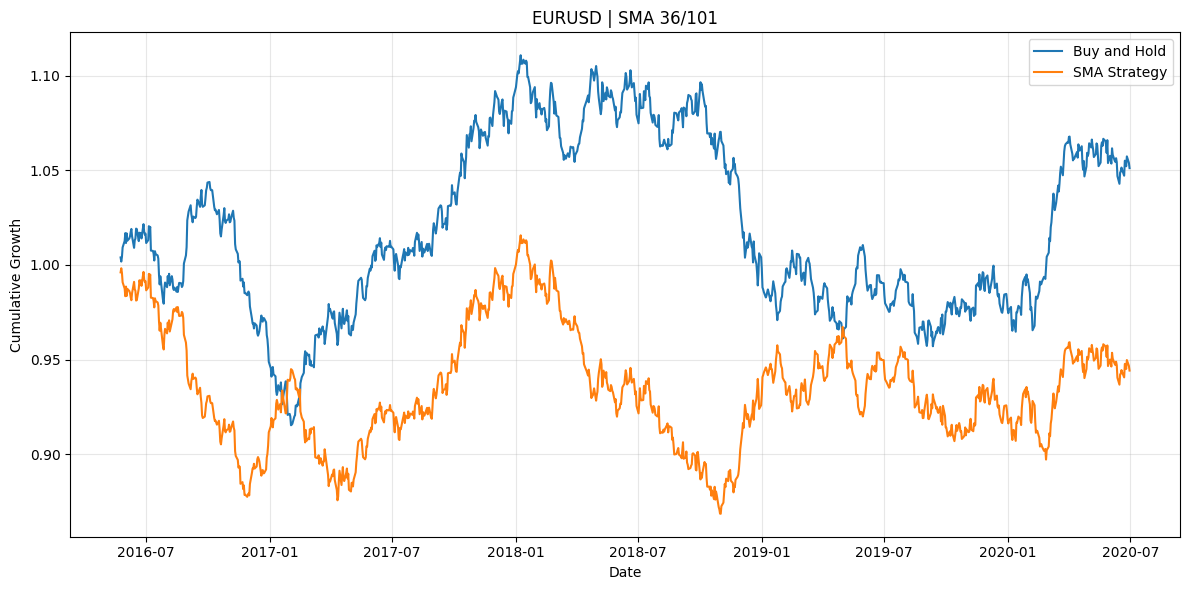

In [11]:
test_tester = SMABacktester("EURUSD", best_sma_short, best_sma_long, "2016-01-01", "2020-06-30")
test_tester.test_strategy()
test_tester.plot_results()


- The strategy is fitted on the training data.
- The selected parameters are then tested on unseen future data.
- Out-of-sample performance is usually weaker than in-sample performance.
- This is one reason forward testing matters so much in systematic trading.


## 9. Test a Second Instrument

A strategy that looks good on one instrument may look much less impressive on another. That is why cross-instrument testing is useful when we want to judge how robust an idea really is.


Strategy Performance: 1.47245
Buy and Hold Performance: 1.142783
Outperformance: 0.329667


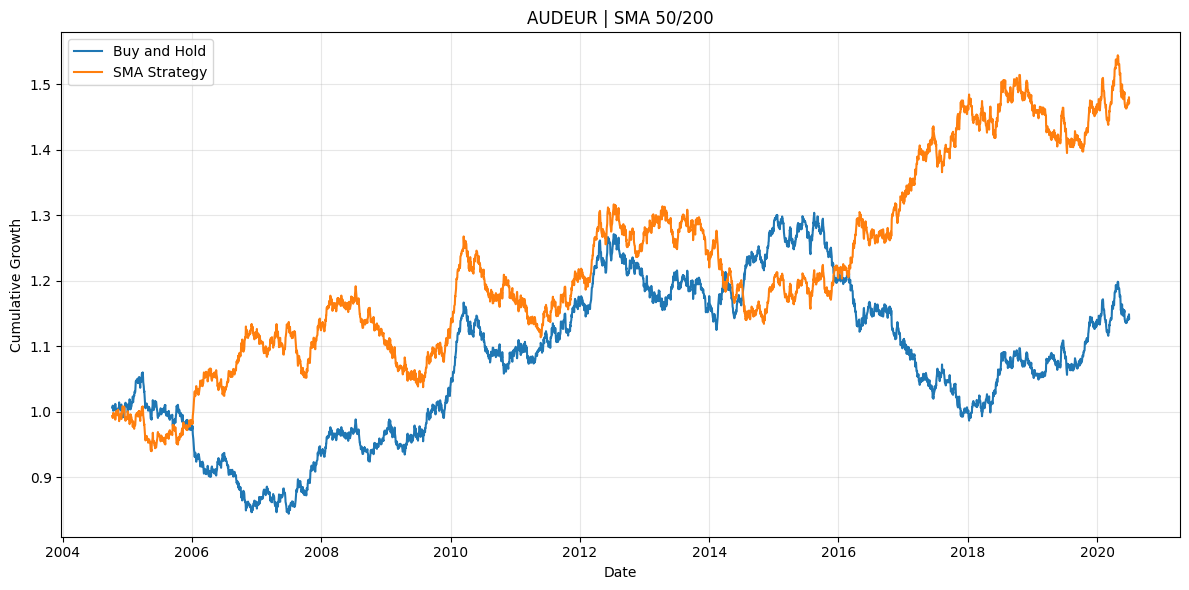

In [12]:
aud_tester = SMABacktester("AUDEUR", 50, 200, "2004-01-01", "2020-06-30")
aud_tester.test_strategy()
aud_tester.plot_results()


AUDEUR best parameters: (44, 192)
AUDEUR best performance: 1.590223

   SMA_Short  SMA_Long  Performance  Outperformance
0         44       192     1.590223        0.465608
1         46       189     1.587585        0.469789
2         45       196     1.583649        0.441396
3         47       190     1.579879        0.463539
4         45       197     1.577275        0.439984
5         48       191     1.568927        0.446451
6         45       194     1.568885        0.435658
7         46       190     1.566972        0.450633
8         44       191     1.565123        0.442647
9         48       190     1.563159        0.446820


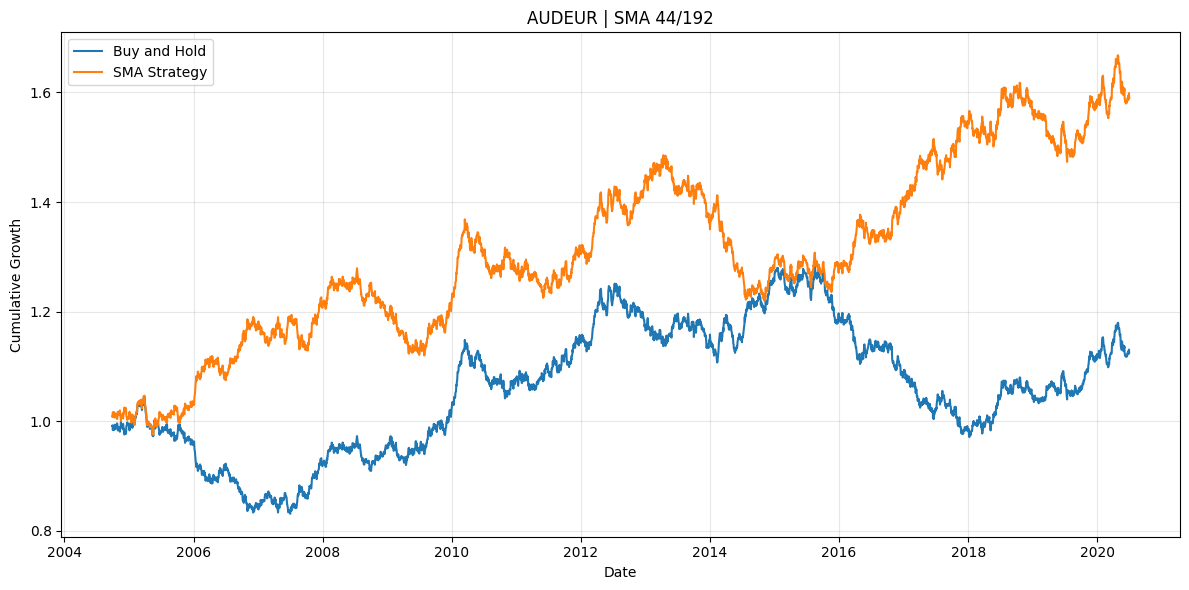

In [13]:
aud_best_params, aud_best_perf = aud_tester.optimize_parameters((25, 50, 1), (100, 200, 1))
print("AUDEUR best parameters:", aud_best_params)
print("AUDEUR best performance:", aud_best_perf)
print()
print(aud_tester.optimization_results.head(10))
aud_tester.plot_results()


If most of the apparent outperformance comes from a short unstable period, the strategy may not be reliable. Looking across multiple instruments helps us separate a genuinely useful idea from a lucky historical pattern.


## 10. Final Summary

- A class makes backtesting reusable and easier to manage.
- SMA crossover strategies can be tested quickly across instruments and parameter values.
- Optimisation finds the best historical parameters, but that does not guarantee future success.
- In-sample and out-of-sample testing are essential.
- Real strategies still need transaction costs, spread, slippage, risk controls, position sizing, and paper/live validation before they are taken seriously.


# Building the SMABacktester Class from Scratch — Part 1: Instantiation and Attributes

In the previous section of this notebook, we used an `SMABacktester` class as a finished tool. That was helpful for seeing what the class can do, but it is also useful to slow down and rebuild it step by step.

A class acts like a **blueprint**. Each specific backtest is represented by an **object** created from that blueprint. For example, one object might store:

- symbol: `AUDEUR`
- short SMA window: `50`
- long SMA window: `200`
- start date: `2004-01-01`
- end date: `2020-06-30`

At this stage, the object will **not** run a strategy yet. It will only store the settings we need for a later backtest.


## 1. Create a Minimal `SMABacktester` Class

We begin with the constructor method, `__init__`. Its job is simple: when we create a new object, it saves the key strategy settings inside that object.


In [14]:
class SMABacktester:
    def __init__(self, symbol, sma_short, sma_long, start, end):
        # Store the strategy settings as object attributes.
        self.symbol = symbol
        self.sma_short = sma_short
        self.sma_long = sma_long
        self.start = start
        self.end = end


A few beginner-friendly notes:

- `self` refers to the specific object we are creating.
- `self.symbol`, `self.sma_short`, and the other names are **attributes** stored inside that object.
- Every time we create a new `SMABacktester(...)`, Python will run `__init__` and save the values we pass in.

So right now the class is not doing any calculations. It is simply remembering the settings for one future backtest.


## 2. Create an Instance of the Class

Now we create one object from the blueprint. This object represents one specific SMA strategy setup for `AUDEUR`.


In [15]:
simple_tester = SMABacktester(
    symbol="AUDEUR",
    sma_short=50,
    sma_long=200,
    start="2004-01-01",
    end="2020-06-30"
)

simple_tester


The output is not very informative yet, because we have not added a custom string representation. But the object has been created successfully, and it now holds the settings we passed in.


In [16]:
print("Symbol:", simple_tester.symbol)
print("Short SMA:", simple_tester.sma_short)
print("Long SMA:", simple_tester.sma_long)
print("Start date:", simple_tester.start)
print("End date:", simple_tester.end)


Symbol: AUDEUR
Short SMA: 50
Long SMA: 200
Start date: 2004-01-01
End date: 2020-06-30


## 3. Inspect the Stored Attributes

A convenient way to see what is stored inside an object is to look at its `__dict__`. This shows the internal attribute dictionary for the object.


In [17]:
simple_tester.__dict__


{'symbol': 'AUDEUR',
 'sma_short': 50,
 'sma_long': 200,
 'start': '2004-01-01',
 'end': '2020-06-30'}

## 4. Why This Matters

This is the first important step in object-oriented backtesting. Before a class can load data, calculate moving averages, or evaluate performance, it needs a place to store the core strategy settings.

In the next step, we can build on this by teaching the class how to load price data and prepare the raw inputs needed for the strategy.


# Building the SMABacktester Class from Scratch — Part 2: The `get_data()` Method

In the previous section, the `SMABacktester` object could remember settings such as the symbol, SMA windows, start date, and end date.

However, before we can test an SMA crossover strategy, we need actual price data. The `get_data()` method will be responsible for preparing the raw market data.

This method will create a DataFrame containing:

- `price`
- `returns`
- `sma_short`
- `sma_long`

Later on, this prepared data will be used to generate trading positions and strategy returns. For now, we are only focusing on the data preparation step.


## 1. Confirm the Required Imports

These are the core libraries we need for this section. They may already have been imported earlier in the notebook, but it is helpful to make the dependencies explicit here as well.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('default')


## 2. Manual Demonstration Before Adding the Method

Before putting the logic into a class method, let’s first write the data preparation steps manually. This helps us understand the exact sequence of operations before we wrap them inside a reusable object-oriented method.


In [19]:
data_path = Path("forex_pairs.csv")

if not data_path.exists():
    np.random.seed(42)

    dates = pd.date_range(start="2004-01-01", end="2020-06-30", freq="B")

    synthetic_data = pd.DataFrame(index=dates)
    synthetic_data["AUDEUR"] = 0.62 * np.exp(np.random.normal(0.00001, 0.005, len(dates)).cumsum())
    synthetic_data["EURUSD"] = 1.20 * np.exp(np.random.normal(0.00002, 0.006, len(dates)).cumsum())
    synthetic_data["USDGBP"] = 0.55 * np.exp(np.random.normal(0.00001, 0.004, len(dates)).cumsum())

    # Add a small number of missing values to mimic real-world data issues
    for column in synthetic_data.columns:
        missing_idx = np.random.choice(len(synthetic_data), size=20, replace=False)
        synthetic_data.iloc[missing_idx, synthetic_data.columns.get_loc(column)] = np.nan

    synthetic_data.to_csv(data_path, index_label="Date")

    print("Synthetic forex_pairs.csv created.")
else:
    print("forex_pairs.csv already exists.")


forex_pairs.csv already exists.


In [20]:
df = pd.read_csv("forex_pairs.csv", parse_dates=["Date"], index_col="Date")

symbol = "AUDEUR"
sma_short = 50
sma_long = 200
start = "2010-01-01"
end = "2012-12-31"

raw = df[[symbol]].dropna().copy()
raw = raw.loc[start:end].copy()
raw.rename(columns={symbol: "price"}, inplace=True)

raw["returns"] = np.log(raw["price"] / raw["price"].shift(1))
raw["sma_short"] = raw["price"].rolling(sma_short).mean()
raw["sma_long"] = raw["price"].rolling(sma_long).mean()

raw.dropna(inplace=True)

raw.head()


,price,returns,sma_short,sma_long
Date,,,,
2010-10-07,0.674205,-0.003843,0.671476,0.684686
2010-10-08,0.671295,-0.004326,0.671434,0.684836
2010-10-11,0.667734,-0.005319,0.671412,0.684936
2010-10-12,0.669869,0.003192,0.671441,0.685045
2010-10-13,0.670653,0.001170,0.671452,0.685157


In [21]:
raw.tail()


,price,returns,sma_short,sma_long
Date,,,,
2012-12-25,0.742145,0.000394,0.751816,0.760128
2012-12-26,0.739292,-0.003852,0.751575,0.760095
2012-12-27,0.734404,-0.006634,0.751160,0.760016
2012-12-28,0.736822,0.003288,0.750741,0.759937
2012-12-31,0.735433,-0.001888,0.750311,0.759846


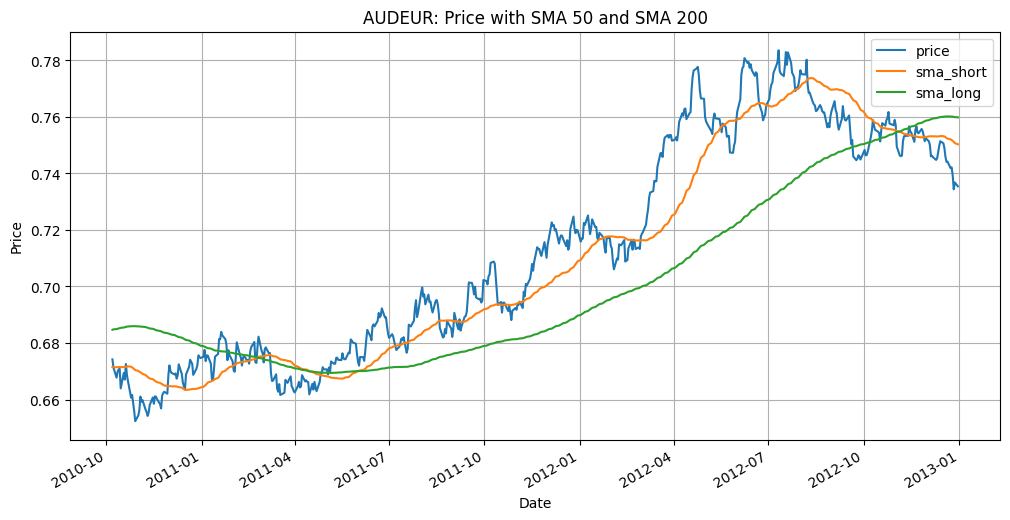

In [22]:
raw[["price", "sma_short", "sma_long"]].plot(figsize=(12, 6))
plt.title(f"{symbol}: Price with SMA {sma_short} and SMA {sma_long}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()


These are the exact steps we want to move into the class method. Once they are inside the class, we will be able to repeat the same preparation logic for different instruments, time periods, and SMA combinations much more easily.


## 3. Add `get_data()` to the Class

Now we move the manual data preparation steps into the `SMABacktester` class. Instead of hard-coding values such as `"AUDEUR"`, `50`, `200`, `"2010-01-01"`, and `"2012-12-31"`, the method will use the values stored on the object:

- `self.symbol`
- `self.sma_short`
- `self.sma_long`
- `self.start`
- `self.end`


In [23]:
class SMABacktester:
    """
    A simple class blueprint for SMA crossover backtesting.

    This version stores the key settings and includes a get_data()
    method that loads and prepares price data.
    """

    def __init__(self, symbol, sma_short, sma_long, start, end, data_path="forex_pairs.csv"):
        self.symbol = symbol
        self.sma_short = sma_short
        self.sma_long = sma_long
        self.start = start
        self.end = end
        self.data_path = data_path

        self.results = None
        self.data = None

    def __repr__(self):
        return (
            f"SMABacktester(symbol={self.symbol}, "
            f"sma_short={self.sma_short}, "
            f"sma_long={self.sma_long}, "
            f"start={self.start}, "
            f"end={self.end})"
        )

    def get_data(self):
        """
        Load price data, select the chosen symbol, calculate returns,
        and calculate the short and long simple moving averages.
        """

        df = pd.read_csv(
            self.data_path,
            parse_dates=["Date"],
            index_col="Date"
        )

        if self.symbol not in df.columns:
            raise ValueError(
                f"Symbol '{self.symbol}' not found in {self.data_path}. "
                f"Available symbols: {list(df.columns)}"
            )

        raw = df[[self.symbol]].dropna().copy()
        raw = raw.loc[self.start:self.end].copy()

        raw.rename(columns={self.symbol: "price"}, inplace=True)

        raw["returns"] = np.log(raw["price"] / raw["price"].shift(1))
        raw["sma_short"] = raw["price"].rolling(self.sma_short).mean()
        raw["sma_long"] = raw["price"].rolling(self.sma_long).mean()

        raw.dropna(inplace=True)

        self.data = raw

        return raw


## 4. Create an Instance and Call `get_data()`

Now we can create a tester object and call the new method. The method reads the settings stored in the object, prepares the data, and stores the result in `tester.data`.


In [24]:
tester = SMABacktester(
    symbol="AUDEUR",
    sma_short=50,
    sma_long=200,
    start="2010-01-01",
    end="2012-12-31"
)

tester


SMABacktester(symbol=AUDEUR, sma_short=50, sma_long=200, start=2010-01-01, end=2012-12-31)

In [25]:
tester.get_data()


,price,returns,sma_short,sma_long
Date,,,,
2010-10-07,0.674205,-0.003843,0.671476,0.684686
2010-10-08,0.671295,-0.004326,0.671434,0.684836
2010-10-11,0.667734,-0.005319,0.671412,0.684936
2010-10-12,0.669869,0.003192,0.671441,0.685045
2010-10-13,0.670653,0.001170,0.671452,0.685157
...,...,...,...,...
2012-12-25,0.742145,0.000394,0.751816,0.760128
2012-12-26,0.739292,-0.003852,0.751575,0.760095
2012-12-27,0.734404,-0.006634,0.751160,0.760016


In [26]:
tester.data.head()


,price,returns,sma_short,sma_long
Date,,,,
2010-10-07,0.674205,-0.003843,0.671476,0.684686
2010-10-08,0.671295,-0.004326,0.671434,0.684836
2010-10-11,0.667734,-0.005319,0.671412,0.684936
2010-10-12,0.669869,0.003192,0.671441,0.685045
2010-10-13,0.670653,0.001170,0.671452,0.685157


In [27]:
tester.data.tail()


,price,returns,sma_short,sma_long
Date,,,,
2012-12-25,0.742145,0.000394,0.751816,0.760128
2012-12-26,0.739292,-0.003852,0.751575,0.760095
2012-12-27,0.734404,-0.006634,0.751160,0.760016
2012-12-28,0.736822,0.003288,0.750741,0.759937
2012-12-31,0.735433,-0.001888,0.750311,0.759846


`tester.data` now stores the prepared price data. This is useful because later methods will be able to work directly with `self.data` instead of repeating the preparation steps every time.


## 5. The Method Uses Object Attributes

The important point is that the method does not rely on hard-coded values. It uses the attributes stored on the object, which means the same method can prepare data for another instrument, date range, and SMA combination without any rewrite.


In [28]:
eur_tester = SMABacktester(
    symbol="EURUSD",
    sma_short=75,
    sma_long=150,
    start="2015-01-01",
    end="2020-06-30"
)

eur_tester.get_data()
eur_tester.data.head()


,price,returns,sma_short,sma_long
Date,,,,
2015-07-29,0.911619,-0.009181,0.883096,0.873290
2015-07-30,0.906624,-0.005494,0.883659,0.873423
2015-07-31,0.912788,0.006776,0.884222,0.873614
2015-08-03,0.914459,0.001829,0.884784,0.873845
2015-08-04,0.911346,-0.003410,0.885267,0.874105


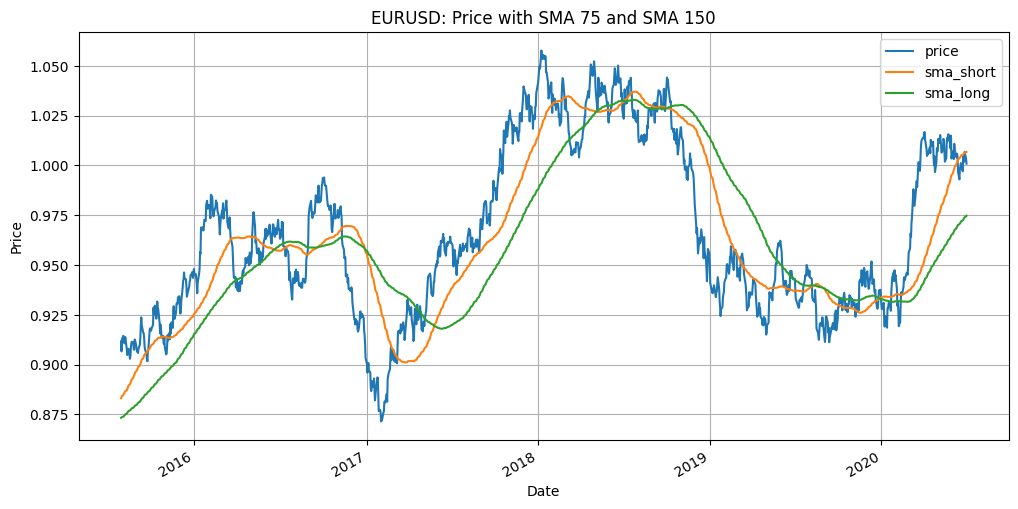

In [29]:
eur_tester.data[["price", "sma_short", "sma_long"]].plot(figsize=(12, 6))
plt.title(f"{eur_tester.symbol}: Price with SMA {eur_tester.sma_short} and SMA {eur_tester.sma_long}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()


The same method works for another instrument and another SMA combination. That is the real strength of the class design: once the method is written once, it becomes reusable.


## 6. Optional Improvement: Call `get_data()` Automatically in `__init__`

At the moment, we create the object first and then manually call `get_data()`. Another option is to call `self.get_data()` inside `__init__`, so the data is loaded automatically as soon as the object is created.


In [30]:
class SMABacktester:
    """
    A simple class blueprint for SMA crossover backtesting.

    This version automatically loads and prepares data during instantiation.
    """

    def __init__(self, symbol, sma_short, sma_long, start, end, data_path="forex_pairs.csv"):
        self.symbol = symbol
        self.sma_short = sma_short
        self.sma_long = sma_long
        self.start = start
        self.end = end
        self.data_path = data_path

        self.results = None
        self.data = None

        self.get_data()

    def __repr__(self):
        return (
            f"SMABacktester(symbol={self.symbol}, "
            f"sma_short={self.sma_short}, "
            f"sma_long={self.sma_long}, "
            f"start={self.start}, "
            f"end={self.end})"
        )

    def get_data(self):
        """
        Load price data, select the chosen symbol, calculate returns,
        and calculate the short and long simple moving averages.
        """

        df = pd.read_csv(
            self.data_path,
            parse_dates=["Date"],
            index_col="Date"
        )

        if self.symbol not in df.columns:
            raise ValueError(
                f"Symbol '{self.symbol}' not found in {self.data_path}. "
                f"Available symbols: {list(df.columns)}"
            )

        raw = df[[self.symbol]].dropna().copy()
        raw = raw.loc[self.start:self.end].copy()

        raw.rename(columns={self.symbol: "price"}, inplace=True)

        raw["returns"] = np.log(raw["price"] / raw["price"].shift(1))
        raw["sma_short"] = raw["price"].rolling(self.sma_short).mean()
        raw["sma_long"] = raw["price"].rolling(self.sma_long).mean()

        raw.dropna(inplace=True)

        self.data = raw

        return raw


In [31]:
auto_tester = SMABacktester(
    symbol="AUDEUR",
    sma_short=50,
    sma_long=200,
    start="2010-01-01",
    end="2012-12-31"
)

auto_tester.data.head()


,price,returns,sma_short,sma_long
Date,,,,
2010-10-07,0.674205,-0.003843,0.671476,0.684686
2010-10-08,0.671295,-0.004326,0.671434,0.684836
2010-10-11,0.667734,-0.005319,0.671412,0.684936
2010-10-12,0.669869,0.003192,0.671441,0.685045
2010-10-13,0.670653,0.001170,0.671452,0.685157


In this version, the data exists immediately after creating the object, because `self.get_data()` runs automatically during instantiation.


## 7. Should `get_data()` Return the DataFrame?

There are two common design choices:

1. `get_data()` stores the prepared DataFrame as `self.data` and also returns it.
2. `get_data()` only stores the prepared DataFrame as `self.data` and does not return anything.

For learning, returning the DataFrame is useful because we can immediately inspect the output in the notebook. For a more production-style class, storing it as `self.data` may be enough.

We keep the current version returning `raw` because it is clearer for notebook learning.


## 8. Final Summary

- We added the first real method to the `SMABacktester` class.
- `get_data()` loads the CSV file.
- It selects the requested instrument using `self.symbol`.
- It restricts the data using `self.start` and `self.end`.
- It renames the price column to `price`.
- It calculates log returns.
- It calculates the short and long SMAs.
- It stores the prepared DataFrame as `self.data`.
- We also showed how to call `get_data()` automatically during object creation.
- This prepared data is the foundation for the next step: generating trading positions and testing the strategy.


# Building the SMABacktester Class from Scratch — Part 3: Updating SMA Parameters Safely

In the previous section, the `SMABacktester` class could retrieve and prepare data. However, we now need a safe way to update the SMA windows.

For example, we may want to test:

- SMA 25 / 150
- SMA 30 / 200
- SMA 75 / 250

But simply overwriting an attribute is dangerous. If we do:

```python
tester.sma_long = 250
```

then the stored parameter changes, but the existing `sma_long` column inside the DataFrame does not automatically update.

That creates an inconsistent object, which is why we need a dedicated method that updates both:

1. the object attribute
2. the related SMA column in `self.data`


## 1. Demonstrate the Problem Manually

We start by creating a tester object using the current class. Then we inspect the stored SMA settings and the prepared data before manually changing one attribute.


In [32]:
tester = SMABacktester(
    symbol="AUDEUR",
    sma_short=50,
    sma_long=200,
    start="2004-01-01",
    end="2020-06-30"
)

tester


SMABacktester(symbol=AUDEUR, sma_short=50, sma_long=200, start=2004-01-01, end=2020-06-30)

In [33]:
# If get_data is not called automatically in the current class version, call it explicitly.
if tester.data is None:
    tester.get_data()

tester.sma_short, tester.sma_long


(50, 200)

In [34]:
tester.data.head()


,price,returns,sma_short,sma_long
Date,,,,
2004-10-06,0.618094,0.003198,0.623921,0.631450
2004-10-07,0.616369,-0.002794,0.624043,0.631282
2004-10-08,0.620337,0.006416,0.624123,0.631133
2004-10-11,0.622206,0.003008,0.624271,0.630991
2004-10-12,0.619708,-0.004022,0.624382,0.630808


In [35]:
df = pd.read_csv("forex_pairs.csv", parse_dates=["Date"], index_col="Date")

raw_check = df[[tester.symbol]].dropna().copy()
raw_check = raw_check.loc[tester.start:tester.end].copy()
raw_check.rename(columns={tester.symbol: "price"}, inplace=True)

raw_check["returns"] = np.log(raw_check["price"] / raw_check["price"].shift(1))
raw_check["sma_short"] = raw_check["price"].rolling(tester.sma_short).mean()
raw_check["sma_long"] = raw_check["price"].rolling(tester.sma_long).mean()

raw_check.isna().sum()


price          0
returns        1
sma_short     49
sma_long     199
dtype: int64

- SMA 50 creates about 49 missing values at the beginning.
- SMA 200 creates about 199 missing values at the beginning.
- This happens because a rolling mean needs enough observations before it can calculate a value.


In [36]:
tester.sma_long = 250
tester.sma_long


250

The attribute now says the long SMA is 250, but unless we recalculate the data, the existing `sma_long` column still represents the old long SMA values. This is exactly the inconsistency we want to avoid.


## 2. Encapsulation in Simple Terms

Encapsulation means that an object should manage its own internal state. Instead of changing linked values manually from outside the object, we create methods that control how those changes happen.

In this case, the SMA settings and the SMA columns in the data are connected. So when we update `sma_short` or `sma_long`, the class should also update the matching columns in `self.data`.

That is why a safer design is:

```python
tester.set_parameters(sma_short=25, sma_long=150)
```

instead of manually doing:

```python
tester.sma_short = 25
tester.sma_long = 150
```


## 3. Redefine the Class with `set_parameters()`

We now extend the class so it can update the SMA settings safely and keep the prepared data consistent with those settings.


In [37]:
class SMABacktester:
    """
    A simple class blueprint for SMA crossover backtesting.

    This version can:
    - store backtest settings
    - load and prepare price data
    - update SMA parameters safely
    """

    def __init__(self, symbol, sma_short, sma_long, start, end, data_path="forex_pairs.csv"):
        self.symbol = symbol
        self.sma_short = sma_short
        self.sma_long = sma_long
        self.start = start
        self.end = end
        self.data_path = data_path

        self.results = None
        self.data = None

        self.get_data()

    def __repr__(self):
        return (
            f"SMABacktester(symbol={self.symbol}, "
            f"sma_short={self.sma_short}, "
            f"sma_long={self.sma_long}, "
            f"start={self.start}, "
            f"end={self.end})"
        )

    def get_data(self):
        """
        Load price data, select the chosen symbol, calculate returns,
        and calculate the short and long simple moving averages.
        """

        df = pd.read_csv(
            self.data_path,
            parse_dates=["Date"],
            index_col="Date"
        )

        if self.symbol not in df.columns:
            raise ValueError(
                f"Symbol '{self.symbol}' not found in {self.data_path}. "
                f"Available symbols: {list(df.columns)}"
            )

        raw = df[[self.symbol]].dropna().copy()
        raw = raw.loc[self.start:self.end].copy()

        raw.rename(columns={self.symbol: "price"}, inplace=True)

        raw["returns"] = np.log(raw["price"] / raw["price"].shift(1))
        raw["sma_short"] = raw["price"].rolling(self.sma_short).mean()
        raw["sma_long"] = raw["price"].rolling(self.sma_long).mean()

        self.data = raw

        return raw

    def set_parameters(self, sma_short=None, sma_long=None):
        """
        Update SMA parameters and recalculate the related SMA columns.

        Parameters
        ----------
        sma_short : int or None
            New short SMA window. If None, the existing value is kept.

        sma_long : int or None
            New long SMA window. If None, the existing value is kept.
        """

        if sma_short is not None:
            self.sma_short = sma_short
            self.data["sma_short"] = self.data["price"].rolling(self.sma_short).mean()

        if sma_long is not None:
            self.sma_long = sma_long
            self.data["sma_long"] = self.data["price"].rolling(self.sma_long).mean()

        # Existing results would no longer match the new parameters
        self.results = None

        return self.data


This method lets the object update itself consistently. If we only change the short SMA, the long SMA remains unchanged. If we only change the long SMA, the short SMA remains unchanged. If we change both, both columns are recalculated.


## 4. Test the New Method

We create a fresh object, inspect the initial missing values, then change both SMA windows and confirm that the rolling columns are recalculated.


In [38]:
tester = SMABacktester(
    symbol="AUDEUR",
    sma_short=50,
    sma_long=200,
    start="2004-01-01",
    end="2020-06-30"
)

tester


SMABacktester(symbol=AUDEUR, sma_short=50, sma_long=200, start=2004-01-01, end=2020-06-30)

In [39]:
tester.sma_short, tester.sma_long


(50, 200)

In [40]:
tester.data[["sma_short", "sma_long"]].isna().sum()


sma_short     49
sma_long     199
dtype: int64

At this point, we expect approximately:

- `sma_short`: 49 missing values
- `sma_long`: 199 missing values


In [41]:
tester.set_parameters(sma_short=25, sma_long=150)


,price,returns,sma_short,sma_long
Date,,,,
2004-01-01,0.650033,NaN,NaN,NaN
2004-01-02,0.650040,0.000011,NaN,NaN
2004-01-05,0.650722,0.001048,NaN,NaN
2004-01-06,0.656196,0.008377,NaN,NaN
2004-01-07,0.657086,0.001355,NaN,NaN
...,...,...,...,...
2020-06-24,0.702872,-0.000228,0.705624,0.708888
2020-06-25,0.706153,0.004658,0.705170,0.708915
2020-06-26,0.703052,-0.004401,0.704799,0.708915


In [42]:
tester.sma_short, tester.sma_long


(25, 150)

In [43]:
tester.data[["sma_short", "sma_long"]].isna().sum()


sma_short     24
sma_long     149
dtype: int64

Now we expect approximately:

- `sma_short`: 24 missing values
- `sma_long`: 149 missing values

That confirms the columns were recalculated using the new rolling windows.


## 5. Plot the Updated SMAs

A quick chart makes it easy to confirm visually that the data now reflects the updated parameter settings.


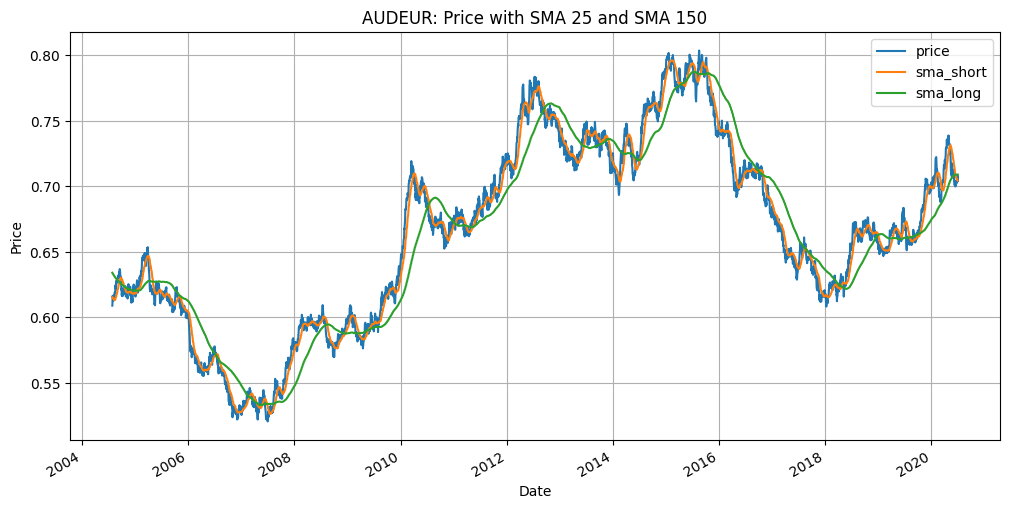

In [44]:
tester.data[["price", "sma_short", "sma_long"]].dropna().plot(figsize=(12, 6))
plt.title(f"{tester.symbol}: Price with SMA {tester.sma_short} and SMA {tester.sma_long}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()


The plot now reflects the updated SMA 25 and SMA 150 windows.


## 6. Update Only One Parameter

The method also lets us update only one SMA at a time, which is useful when we want to keep one rolling window fixed and change only the other.


In [45]:
tester.set_parameters(sma_short=30)
tester.sma_short, tester.sma_long


(30, 150)

In [46]:
tester.data[["sma_short", "sma_long"]].isna().sum()


sma_short     29
sma_long     149
dtype: int64

Here the short SMA has changed, while the long SMA remains unchanged.


In [47]:
tester.set_parameters(sma_long=180)
tester.sma_short, tester.sma_long


(30, 180)

In [48]:
tester.data[["sma_short", "sma_long"]].isna().sum()


sma_short     29
sma_long     179
dtype: int64

Now the long SMA has changed, while the short SMA remains at its previous value.


## 7. Design Decision: Why Not Update Symbol or Dates?

In this version of the class, `set_parameters()` only updates the SMA windows. If we want to test a different symbol or a different time period, the cleaner approach is to create a new object, for example:

```python
eur_tester = SMABacktester(
    symbol="EURUSD",
    sma_short=50,
    sma_long=200,
    start="2010-01-01",
    end="2020-06-30"
)
```

This is a design choice. We could extend `set_parameters()` to also update the symbol, start date, and end date. But for learning purposes, keeping the method focused on SMA parameters makes the class easier to understand.


## 8. Final Summary

- Directly overwriting attributes can create inconsistent objects.
- If we change `tester.sma_long`, the existing `sma_long` column in `tester.data` does not automatically update.
- This is why we added a `set_parameters()` method.
- `set_parameters()` updates the SMA attributes and recalculates the matching columns in the data.
- This is an example of encapsulation: the object controls how its internal state changes.
- We can update only the short SMA, only the long SMA, or both.
- In this version, changing the symbol or date range should be done by creating a new object.
- The next step will be to use the prepared data to generate trading positions and calculate strategy returns.


# Building the SMABacktester Class from Scratch — Part 4: Testing the Strategy and Returning Performance Metrics

We are now coming to the heart of the class: actually testing the SMA crossover strategy and returning performance metrics.

So far, the class can load data and update SMA parameters safely. The next step is to use that prepared data to create trading positions, calculate strategy returns, and compare the strategy against buy and hold.

In this section we will add a `test_strategy()` method that returns two key metrics:

- **absolute performance** of the strategy
- **outperformance** relative to buy and hold


## 1. What the `test_strategy()` Method Should Do

The method takes only `self`, because all required settings are already stored inside the object.

The workflow is:

1. Start from `self.data` and create a copy so we do not overwrite the raw prepared data.
2. Drop the first rows with missing values.
3. Create a `position` column:
   - `1` when `sma_short > sma_long`
   - `-1` otherwise
4. Create a `strategy` column using shifted positions to avoid look-ahead bias.
5. Calculate cumulative buy-and-hold performance (`cret`).
6. Calculate cumulative strategy performance (`cstrategy`).
7. Store the finished result in `self.results`.
8. Return the strategy performance and the outperformance versus buy and hold.


## 2. Redefine the Class with `test_strategy()`

We now extend the class by adding the strategy-testing method. Notice that `self.data` remains the prepared input data, while the full backtest output will be stored separately in `self.results`.


In [50]:
class SMABacktester:
    """
    A simple class blueprint for SMA crossover backtesting.

    This version can:
    - store backtest settings
    - load and prepare price data
    - update SMA parameters safely
    - test the SMA crossover strategy
    """

    def __init__(self, symbol, sma_short, sma_long, start, end, data_path="forex_pairs.csv"):
        self.symbol = symbol
        self.sma_short = sma_short
        self.sma_long = sma_long
        self.start = start
        self.end = end
        self.data_path = data_path

        self.results = None
        self.data = None

        self.get_data()

    def __repr__(self):
        return (
            f"SMABacktester(symbol={self.symbol}, "
            f"sma_short={self.sma_short}, "
            f"sma_long={self.sma_long}, "
            f"start={self.start}, "
            f"end={self.end})"
        )

    def get_data(self):
        """Load price data and prepare returns plus both moving averages."""
        df = pd.read_csv(
            self.data_path,
            parse_dates=["Date"],
            index_col="Date"
        )

        if self.symbol not in df.columns:
            raise ValueError(
                f"Symbol '{self.symbol}' not found in {self.data_path}. "
                f"Available symbols: {list(df.columns)}"
            )

        raw = df[[self.symbol]].dropna().copy()
        raw = raw.loc[self.start:self.end].copy()
        raw.rename(columns={self.symbol: "price"}, inplace=True)

        raw["returns"] = np.log(raw["price"] / raw["price"].shift(1))
        raw["sma_short"] = raw["price"].rolling(self.sma_short).mean()
        raw["sma_long"] = raw["price"].rolling(self.sma_long).mean()

        self.data = raw
        self.results = None
        return raw

    def set_parameters(self, sma_short=None, sma_long=None):
        """Update SMA parameters and recalculate the related SMA columns."""
        if sma_short is not None:
            self.sma_short = sma_short
            self.data["sma_short"] = self.data["price"].rolling(self.sma_short).mean()

        if sma_long is not None:
            self.sma_long = sma_long
            self.data["sma_long"] = self.data["price"].rolling(self.sma_long).mean()

        self.results = None
        return self.data

    def test_strategy(self):
        """Create positions, calculate strategy returns, and return key performance metrics."""
        data = self.data.copy()

        # Remove rows where moving averages are not yet available.
        data = data.dropna().copy()

        # Long when the short SMA is above the long SMA, short otherwise.
        data["position"] = np.where(data["sma_short"] > data["sma_long"], 1, -1)

        # Shift the position so that today's signal is traded on the next day.
        data["strategy"] = data["position"].shift(1) * data["returns"]

        # Remove the first row after shifting because it becomes missing.
        data = data.dropna().copy()

        # Growth of 1 unit invested for buy and hold and for the strategy.
        data["cret"] = np.exp(data["returns"].cumsum())
        data["cstrategy"] = np.exp(data["strategy"].cumsum())

        # Store the finished backtest output separately from self.data.
        self.results = data

        performance = round(float(data["cstrategy"].iloc[-1]), 6)
        outperformance = round(float(data["cstrategy"].iloc[-1] - data["cret"].iloc[-1]), 6)

        print(f"Strategy Performance: {performance}")
        print(f"Outperformance vs Buy and Hold: {outperformance}")

        return performance, outperformance


## 3. Create an Instance and Run the Strategy Test

We now create a familiar EUR/USD object and test the strategy. The goal here is to see that the class-based method gives us the same kind of result we got earlier when we worked outside the class.


In [51]:
tester = SMABacktester(
    symbol="EURUSD",
    sma_short=50,
    sma_long=200,
    start="2004-01-01",
    end="2020-06-30"
)

print(tester)


SMABacktester(symbol=EURUSD, sma_short=50, sma_long=200, start=2004-01-01, end=2020-06-30)


In [52]:
tester.test_strategy()


Strategy Performance: 0.945597
Outperformance vs Buy and Hold: 0.091777


(0.945597, 0.091777)

A result like `1.28` would mean that an initial investment of 1 unit grew to 1.28 units over the backtest period.

The **outperformance** tells us how much better or worse the strategy performed compared with buy and hold. A positive value means the strategy beat the benchmark. A negative value means it underperformed.


## 4. Confirm That `self.data` Stays Untouched

One important design choice is that `test_strategy()` should not overwrite the raw prepared data. Instead, it should leave `self.data` untouched and place the full backtest output in `self.results`.


In [53]:
tester.data.head()


,price,returns,sma_short,sma_long
Date,,,,
2004-01-01,1.201671,NaN,NaN,NaN
2004-01-02,1.196084,-0.004660,NaN,NaN
2004-01-05,1.200154,0.003397,NaN,NaN
2004-01-06,1.205269,0.004253,NaN,NaN
2004-01-07,1.194757,-0.008760,NaN,NaN


Notice that `self.data` still contains only the prepared columns:

- `price`
- `returns`
- `sma_short`
- `sma_long`

It does **not** contain the strategy-specific output columns.


In [54]:
tester.results.head()


,price,returns,sma_short,sma_long,position,strategy,cret,cstrategy
Date,,,,,,,,
2004-10-07,1.174045,0.001539,1.158880,1.184415,-1,-0.001539,1.001540,0.998462
2004-10-08,1.181528,0.006354,1.159370,1.184342,-1,-0.006354,1.007924,0.992138
2004-10-11,1.182034,0.000428,1.160044,1.184252,-1,-0.000428,1.008355,0.991714
2004-10-12,1.185487,0.002918,1.160836,1.184153,-1,-0.002918,1.011301,0.988825
2004-10-13,1.174624,-0.009206,1.161417,1.184052,-1,0.009206,1.002034,0.997970


Here in `tester.results` we now have the full backtest output, including the additional columns:

- `position`
- `strategy`
- `cret`
- `cstrategy`

So the class now keeps a clean separation:

- `self.data` = prepared market data
- `self.results` = completed strategy backtest results


In [55]:
tester.results.tail(1)


,price,returns,sma_short,sma_long,position,strategy,cret,cstrategy
Date,,,,,,,,
2020-06-30,1.000881,-0.002656,1.006174,0.964292,1,-0.002656,0.853819,0.945597


In the last row, we can read the final cumulative buy-and-hold value from `cret`, the final cumulative strategy value from `cstrategy`, and their difference, which is the outperformance we returned.


## 5. Final Summary

- We added the `test_strategy()` method to the class.
- The method creates positions from the SMA relationship.
- It calculates strategy returns using `position.shift(1) * returns` to avoid look-ahead bias.
- It calculates cumulative buy-and-hold performance and cumulative strategy performance.
- It stores the full backtest output in `self.results`.
- It leaves `self.data` untouched as the prepared raw input data.
- It returns two key metrics: absolute performance and outperformance versus buy and hold.
- This gives us the core backtesting workflow inside the class.


# Building the SMABacktester Class from Scratch — Part 5: Plotting Strategy Results

In the previous section, the `test_strategy()` method returned two useful numbers:

- absolute strategy performance
- outperformance compared to buy and hold

These metrics are useful, but they do not tell the full story. A strategy may outperform buy and hold overall, but the outperformance might:

- happen only during one short period
- be unstable over time
- disappear for many years
- come with long periods of underperformance

This is why visualising the cumulative performance is important. The `plot_results()` method will plot:

- `creturns`: cumulative buy-and-hold performance
- `cstrategy`: cumulative SMA strategy performance


## 1. Manual Plot First

Before adding the plotting logic to the class, let’s manually plot the results from the previous backtest.


In [56]:
tester = SMABacktester(
    symbol="EURUSD",
    sma_short=50,
    sma_long=200,
    start="2004-01-01",
    end="2020-06-30"
)

tester.test_strategy()

# The earlier class version stored buy-and-hold as `cret`.
# Create `creturns` here so the plotting example matches the new naming.
if "creturns" not in tester.results.columns and "cret" in tester.results.columns:
    tester.results["creturns"] = tester.results["cret"]


Strategy Performance: 0.945597
Outperformance vs Buy and Hold: 0.091777


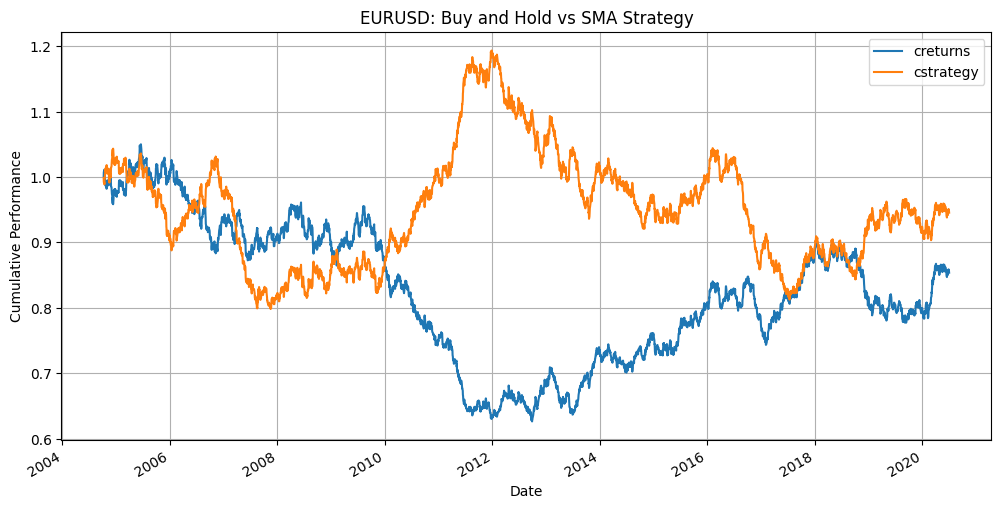

In [57]:
tester.results[["creturns", "cstrategy"]].plot(figsize=(12, 6))
plt.title("EURUSD: Buy and Hold vs SMA Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Performance")
plt.grid(True)
plt.show()


This chart gives a clearer view of whether the strategy outperformed steadily or only during certain periods.


## 2. Why We Need an `if`-Statement

There is one important issue. When a new `SMABacktester` object is created, the `results` attribute starts as `None`. That means there are no backtest results to plot until `test_strategy()` has been called.

So the plotting method should check whether results exist. If `self.results` is `None`, the method should print:

```python
"Run test_strategy() first."
```

This prevents an error and gives the user a helpful message.


## 3. Redefine the Class with `plot_results()`

Now we add a `plot_results()` method to the class. The method will:

1. check whether `self.results` exists
2. if not, tell the user to run `test_strategy()` first
3. if results exist, plot `creturns` and `cstrategy`
4. add a clear title using the symbol and SMA windows


In [58]:
class SMABacktester:
    """
    A simple class blueprint for SMA crossover backtesting.

    This version can:
    - store backtest settings
    - load and prepare price data
    - update SMA parameters safely
    - test an SMA crossover strategy
    - plot strategy results
    """

    def __init__(self, symbol, sma_short, sma_long, start, end, data_path="forex_pairs.csv"):
        self.symbol = symbol
        self.sma_short = sma_short
        self.sma_long = sma_long
        self.start = start
        self.end = end
        self.data_path = data_path

        self.results = None
        self.data = None

        self.get_data()

    def __repr__(self):
        return (
            f"SMABacktester(symbol={self.symbol}, "
            f"sma_short={self.sma_short}, "
            f"sma_long={self.sma_long}, "
            f"start={self.start}, "
            f"end={self.end})"
        )

    def get_data(self):
        """
        Load price data, select the chosen symbol, calculate returns,
        and calculate the short and long simple moving averages.
        """
        df = pd.read_csv(
            self.data_path,
            parse_dates=["Date"],
            index_col="Date"
        )

        if self.symbol not in df.columns:
            raise ValueError(
                f"Symbol '{self.symbol}' not found in {self.data_path}. "
                f"Available symbols: {list(df.columns)}"
            )

        raw = df[[self.symbol]].dropna().copy()
        raw = raw.loc[self.start:self.end].copy()
        raw.rename(columns={self.symbol: "price"}, inplace=True)

        raw["returns"] = np.log(raw["price"] / raw["price"].shift(1))
        raw["sma_short"] = raw["price"].rolling(self.sma_short).mean()
        raw["sma_long"] = raw["price"].rolling(self.sma_long).mean()

        self.data = raw
        self.results = None
        return raw

    def set_parameters(self, sma_short=None, sma_long=None):
        """Update SMA parameters and recalculate the related SMA columns."""
        if sma_short is not None:
            self.sma_short = sma_short
            self.data["sma_short"] = self.data["price"].rolling(self.sma_short).mean()

        if sma_long is not None:
            self.sma_long = sma_long
            self.data["sma_long"] = self.data["price"].rolling(self.sma_long).mean()

        # Existing results would no longer match the new parameters
        self.results = None
        return self.data

    def test_strategy(self):
        """
        Backtest the SMA crossover strategy.

        Returns
        -------
        tuple
            Absolute strategy performance and outperformance versus buy and hold.
        """
        data = self.data.copy().dropna()

        # Generate trading positions:
        # long = 1 when short SMA is above long SMA
        # short = -1 otherwise
        data["position"] = np.where(data["sma_short"] > data["sma_long"], 1, -1)

        # Use yesterday's position for today's return to avoid look-ahead bias
        data["strategy"] = data["position"].shift(1) * data["returns"]

        data.dropna(inplace=True)

        # Cumulative buy-and-hold performance
        data["creturns"] = np.exp(data["returns"].cumsum())

        # Cumulative strategy performance
        data["cstrategy"] = np.exp(data["strategy"].cumsum())

        # Store full backtest result
        self.results = data

        absolute_performance = data["cstrategy"].iloc[-1]
        buy_and_hold_performance = data["creturns"].iloc[-1]
        outperformance = absolute_performance - buy_and_hold_performance

        return round(absolute_performance, 6), round(outperformance, 6)

    def plot_results(self):
        """
        Plot cumulative buy-and-hold performance and cumulative strategy performance.
        """

        if self.results is None:
            print("Run test_strategy() first.")
        else:
            title = (
                f"{self.symbol}: SMA Strategy "
                f"({self.sma_short}, {self.sma_long}) "
                f"from {self.start} to {self.end}"
            )

            self.results[["creturns", "cstrategy"]].plot(figsize=(12, 6))
            plt.title(title)
            plt.xlabel("Date")
            plt.ylabel("Cumulative Performance")
            plt.grid(True)
            plt.show()


## 4. Test the `if`-Statement

First, we create a new object but do not run the strategy yet. Because `test_strategy()` has not been run, `self.results` is still `None`, so the method should tell us to run the backtest first.


In [59]:
tester = SMABacktester(
    symbol="EURUSD",
    sma_short=50,
    sma_long=200,
    start="2004-01-01",
    end="2020-06-30"
)

tester.plot_results()


Run test_strategy() first.


Because `test_strategy()` has not been run yet, `self.results` is still `None`. The method correctly tells us to run `test_strategy()` first.


## 5. Run the Strategy and Plot the Result

Now we run the backtest and call `plot_results()` again.


In [60]:
tester.test_strategy()


(np.float64(0.945597), np.float64(0.091777))

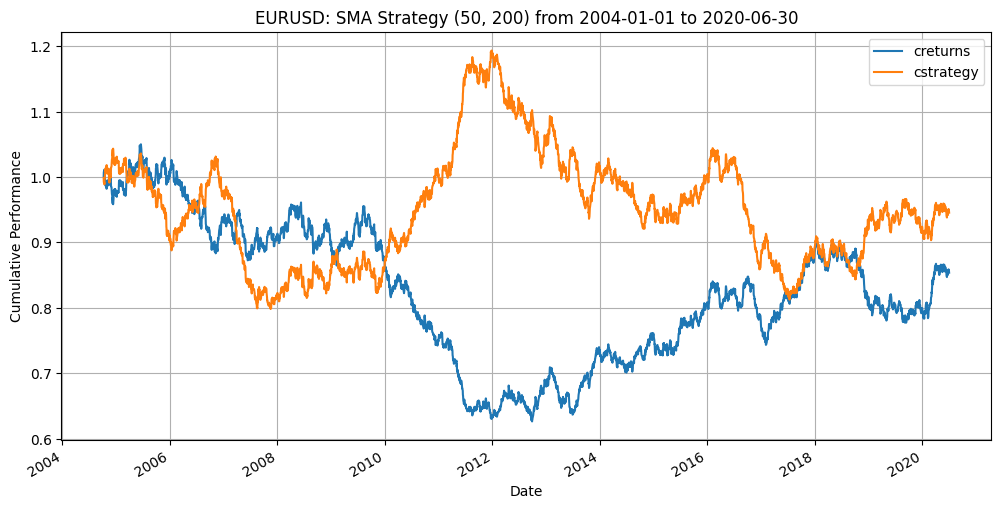

In [61]:
tester.plot_results()


The chart compares the cumulative performance of:

- buy and hold
- the SMA crossover strategy

Even if the SMA strategy outperforms by the end, we should still inspect whether the outperformance is stable over time.


## 6. Inspect the Results Behind the Chart

The plotted lines come directly from the `creturns` and `cstrategy` columns stored in `self.results`.


In [62]:
tester.results[["creturns", "cstrategy"]].tail()


,creturns,cstrategy
Date,,
2020-06-24,0.856307,0.948352
2020-06-25,0.854617,0.946481
2020-06-26,0.858861,0.951180
2020-06-29,0.856090,0.948112
2020-06-30,0.853819,0.945597


The final values in these columns are the same values used to calculate the performance metrics.


In [63]:
tester.test_strategy()


(np.float64(0.945597), np.float64(0.091777))

The first value is the final cumulative strategy performance. The second value is the strategy's outperformance relative to buy and hold.


## 7. Plot a Different SMA Setting

Now that we have a plotting method, we can easily compare a different SMA strategy.


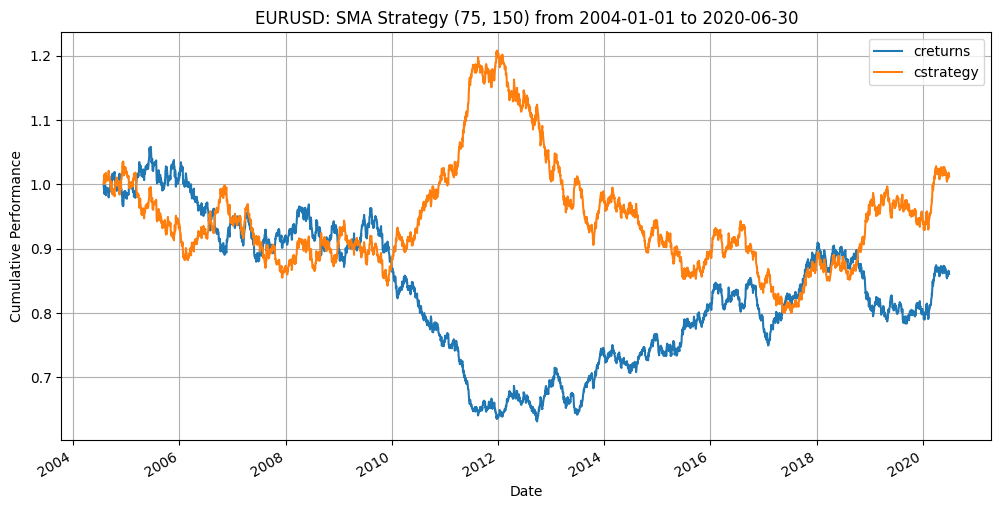

In [64]:
tester.set_parameters(sma_short=75, sma_long=150)
tester.test_strategy()
tester.plot_results()


The chart now reflects the updated SMA 75 / SMA 150 strategy. This shows why the class is useful: once the methods are defined, we can test and visualise another strategy with only a few lines of code.


## 8. Plot Another Instrument

To test another instrument, we create a new object.


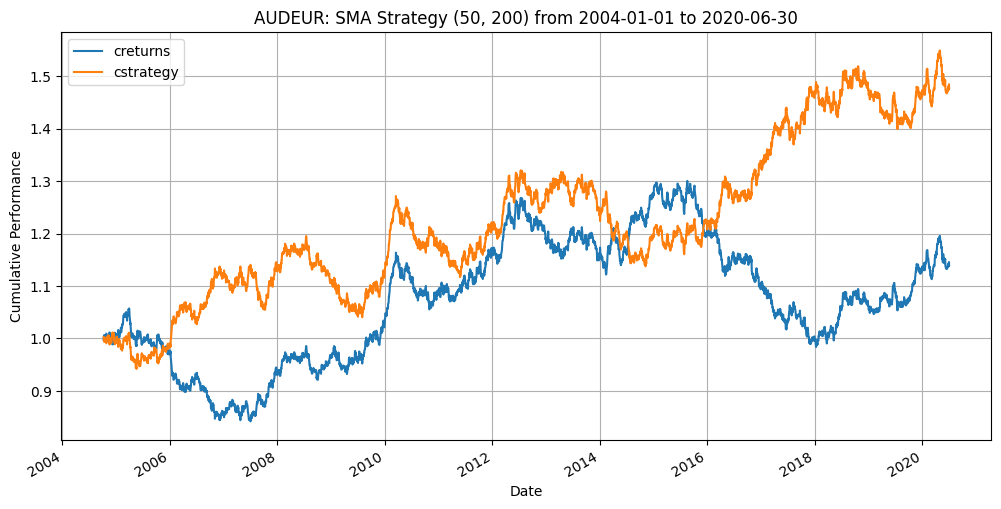

In [65]:
aud_tester = SMABacktester(
    symbol="AUDEUR",
    sma_short=50,
    sma_long=200,
    start="2004-01-01",
    end="2020-06-30"
)

aud_tester.test_strategy()
aud_tester.plot_results()


The visual result may look very different from EURUSD. This is an important reminder that the same strategy may behave differently across instruments.


## 9. Final Summary

- We added a `plot_results()` method.
- The method checks whether `test_strategy()` has already been run.
- If no results exist yet, it prints `Run test_strategy() first.`
- If results exist, it plots cumulative buy-and-hold performance and cumulative SMA strategy performance.
- Visual inspection is important because final performance metrics alone can be misleading.
- A strategy may outperform overall but still be unstable or unreliable through time.
- The next step will be to add optimisation so we can search across many SMA parameter combinations.


# Building the SMABacktester Class from Scratch — Part 6: Optimising SMA Parameters

In the previous sections, we could manually change SMA parameters using:

```python
tester.set_parameters(sma_short=25, sma_long=150)
tester.test_strategy()
```

This works well for testing one combination at a time. However, if we want to find the best SMA combination over a wider range, manually testing each pair would be slow and repetitive.

For example, we may want to test:

- short SMA values from 10 to 50
- long SMA values from 100 to 250

The `optimize_parameters()` method will automate this process. It will:

1. create all possible SMA combinations within the selected ranges
2. test each combination
3. store the performance result
4. find the best-performing combination
5. reset the object to the optimal parameters
6. store all tested combinations in a results DataFrame

**Important warning:** this is an in-sample optimisation. It finds the best parameters on the historical data provided, but this does not guarantee future performance. Later, we should test the chosen parameters on unseen out-of-sample data.


## 1. Import `product`

`product()` helps us create every possible pair of short and long SMA windows.


In [66]:
from itertools import product


For example, the code below:

```python
list(product([10, 20], [100, 200]))
```

creates:

```python
[(10, 100), (10, 200), (20, 100), (20, 200)]
```


## 2. Demonstrate the Optimisation Idea Manually

Before adding the method to the class, let’s manually create some SMA combinations.


In [67]:
sma_short_range = (10, 15, 1)
sma_long_range = (100, 105, 1)

combinations = list(product(
    range(*sma_short_range),
    range(*sma_long_range)
))

combinations[:10]


[(10, 100),
 (10, 101),
 (10, 102),
 (10, 103),
 (10, 104),
 (11, 100),
 (11, 101),
 (11, 102),
 (11, 103),
 (11, 104)]

In [68]:
len(combinations)


25

Each tuple represents one strategy configuration:

```python
(sma_short, sma_long)
```

For example, `(10, 100)` means SMA 10 / SMA 100.


## 3. Manually Test a Small Set of Combinations

Now we can loop through these combinations, update the tester object, run the strategy, and store the performance. This manual workflow is exactly what we want to move into a class method.


In [70]:
tester = SMABacktester(
    symbol="EURUSD",
    sma_short=50,
    sma_long=200,
    start="2004-01-01",
    end="2020-06-30"
)

results = []

for sma_short, sma_long in combinations:
    tester.set_parameters(sma_short=sma_short, sma_long=sma_long)
    performance, outperformance = tester.test_strategy()

    results.append({
        "sma_short": sma_short,
        "sma_long": sma_long,
        "performance": performance,
        "outperformance": outperformance
    })

manual_results = pd.DataFrame(results)
manual_results.head()


,sma_short,sma_long,performance,outperformance
0,10,100,0.875942,0.024497
1,10,101,0.899757,0.046879
2,10,102,0.941965,0.094075
3,10,103,0.942571,0.093338
4,10,104,0.938684,0.092282


In [71]:
manual_results.sort_values("performance", ascending=False).head()


,sma_short,sma_long,performance,outperformance
21,14,101,1.044017,0.191139
22,14,102,1.041081,0.193191
19,13,104,1.032452,0.186050
23,14,103,1.030196,0.180963
24,14,104,1.021166,0.174764


The best row shows the highest historical cumulative strategy performance within this small test range.


## 4. Redefine the Class with `optimize_parameters()`

Now we add the `optimize_parameters()` method to the class.

The method accepts two tuple arguments such as:

```python
sma_short_range=(10, 50, 1)
sma_long_range=(100, 250, 1)
```

Each tuple follows the same pattern as Python's `range()`:

```python
(start, stop, step)
```

The `stop` value is exclusive. So `(10, 50, 1)` tests 10 up to 49, not 50.


In [72]:
class SMABacktester:
    """
    A simple class blueprint for SMA crossover backtesting.

    This version can:
    - store backtest settings
    - load and prepare price data
    - update SMA parameters safely
    - test an SMA crossover strategy
    - plot strategy results
    - optimise SMA parameters
    """

    def __init__(self, symbol, sma_short, sma_long, start, end, data_path="forex_pairs.csv"):
        self.symbol = symbol
        self.sma_short = sma_short
        self.sma_long = sma_long
        self.start = start
        self.end = end
        self.data_path = data_path

        self.results = None
        self.data = None
        self.optimization_results = None

        self.get_data()

    def __repr__(self):
        return (
            f"SMABacktester(symbol={self.symbol}, "
            f"sma_short={self.sma_short}, "
            f"sma_long={self.sma_long}, "
            f"start={self.start}, "
            f"end={self.end})"
        )

    def get_data(self):
        """
        Load price data, select the chosen symbol, calculate returns,
        and calculate the short and long simple moving averages.
        """

        df = pd.read_csv(
            self.data_path,
            parse_dates=["Date"],
            index_col="Date"
        )

        if self.symbol not in df.columns:
            raise ValueError(
                f"Symbol '{self.symbol}' not found in {self.data_path}. "
                f"Available symbols: {list(df.columns)}"
            )

        raw = df[[self.symbol]].dropna().copy()
        raw = raw.loc[self.start:self.end].copy()

        raw.rename(columns={self.symbol: "price"}, inplace=True)

        raw["returns"] = np.log(raw["price"] / raw["price"].shift(1))
        raw["sma_short"] = raw["price"].rolling(self.sma_short).mean()
        raw["sma_long"] = raw["price"].rolling(self.sma_long).mean()

        self.data = raw
        return raw

    def set_parameters(self, sma_short=None, sma_long=None):
        """
        Update SMA parameters and recalculate the related SMA columns.
        """

        if sma_short is not None:
            self.sma_short = sma_short
            self.data["sma_short"] = self.data["price"].rolling(self.sma_short).mean()

        if sma_long is not None:
            self.sma_long = sma_long
            self.data["sma_long"] = self.data["price"].rolling(self.sma_long).mean()

        # Existing results would no longer match the new parameters
        self.results = None

        return self.data

    def test_strategy(self):
        """
        Backtest the SMA crossover strategy.

        Returns
        -------
        tuple
            Absolute strategy performance and outperformance versus buy and hold.
        """

        data = self.data.copy().dropna()

        # Generate trading positions:
        # long = 1 when short SMA is above long SMA
        # short = -1 otherwise
        data["position"] = np.where(data["sma_short"] > data["sma_long"], 1, -1)

        # Use yesterday's position for today's return to avoid look-ahead bias
        data["strategy"] = data["position"].shift(1) * data["returns"]

        data.dropna(inplace=True)

        # Cumulative buy-and-hold performance
        data["creturns"] = np.exp(data["returns"].cumsum())

        # Cumulative strategy performance
        data["cstrategy"] = np.exp(data["strategy"].cumsum())

        # Store full backtest result
        self.results = data

        absolute_performance = data["cstrategy"].iloc[-1]
        buy_and_hold_performance = data["creturns"].iloc[-1]
        outperformance = absolute_performance - buy_and_hold_performance

        return round(absolute_performance, 6), round(outperformance, 6)

    def plot_results(self):
        """
        Plot cumulative buy-and-hold performance and cumulative strategy performance.
        """

        if self.results is None:
            print("Run test_strategy() first.")
        else:
            title = (
                f"{self.symbol}: SMA Strategy "
                f"({self.sma_short}, {self.sma_long}) "
                f"from {self.start} to {self.end}"
            )

            self.results[["creturns", "cstrategy"]].plot(figsize=(12, 6))
            plt.title(title)
            plt.xlabel("Date")
            plt.ylabel("Cumulative Performance")
            plt.grid(True)
            plt.show()

    def optimize_parameters(self, sma_short_range, sma_long_range):
        """
        Brute-force optimisation of SMA parameters.

        Parameters
        ----------
        sma_short_range : tuple
            Tuple in the form (start, stop, step) for short SMA values.

        sma_long_range : tuple
            Tuple in the form (start, stop, step) for long SMA values.

        Returns
        -------
        tuple
            Best parameter combination and best strategy performance.
        """

        combinations = list(product(
            range(*sma_short_range),
            range(*sma_long_range)
        ))

        results = []

        for sma_short, sma_long in combinations:

            # A short SMA should be shorter than the long SMA
            if sma_short >= sma_long:
                continue

            self.set_parameters(sma_short=sma_short, sma_long=sma_long)
            performance, outperformance = self.test_strategy()

            results.append({
                "sma_short": sma_short,
                "sma_long": sma_long,
                "performance": performance,
                "outperformance": outperformance
            })

        self.optimization_results = pd.DataFrame(results)

        if self.optimization_results.empty:
            raise ValueError("No valid SMA combinations were tested. Check the parameter ranges.")

        best_row = self.optimization_results.loc[
            self.optimization_results["performance"].idxmax()
        ]

        best_sma_short = int(best_row["sma_short"])
        best_sma_long = int(best_row["sma_long"])
        best_performance = round(float(best_row["performance"]), 6)

        # Reset the object to the optimal parameters
        self.set_parameters(best_sma_short, best_sma_long)

        # Run the best strategy once more so self.results matches the optimum
        self.test_strategy()

        return (best_sma_short, best_sma_long), best_performance


## 5. Test the Basic Strategy First

Before optimisation, let’s test the default SMA 50 / SMA 200 strategy. This gives us a baseline strategy to compare against the optimised version.


In [73]:
tester = SMABacktester(
    symbol="EURUSD",
    sma_short=50,
    sma_long=200,
    start="2004-01-01",
    end="2020-06-30"
)

tester.test_strategy()


(np.float64(0.945597), np.float64(0.091777))

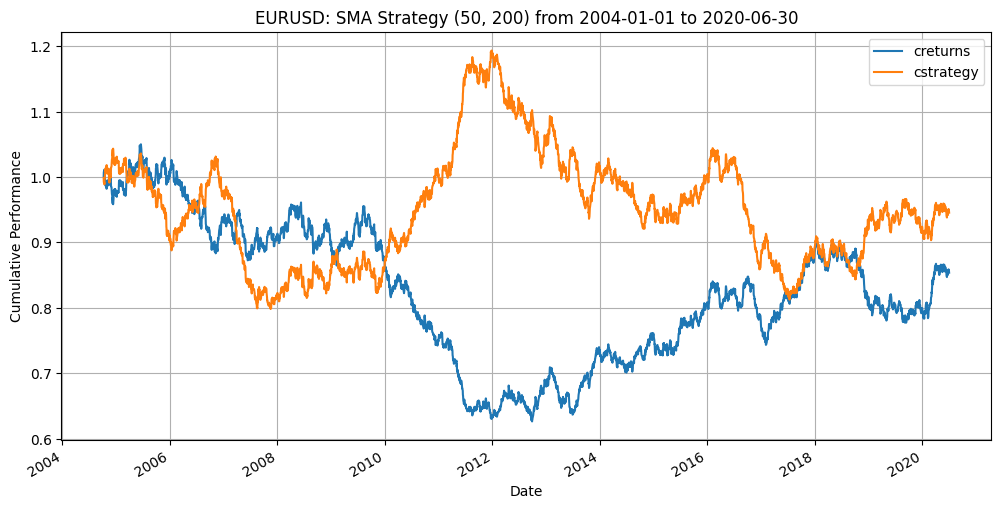

In [74]:
tester.plot_results()


## 6. Optimise SMA Parameters

Now we optimise the SMA parameters. Because Python's `range()` stop value is exclusive, we use `(10, 51, 1)` and `(100, 251, 1)` to include 50 and 250 in the search.


In [75]:
best_params, best_performance = tester.optimize_parameters(
    sma_short_range=(10, 51, 1),
    sma_long_range=(100, 251, 1)
)

best_params, best_performance


((50, 248), 1.398686)

The first returned value is the best SMA parameter combination. The second returned value is the best historical cumulative strategy performance. The exact best values may differ if synthetic data is being used.


## 7. Confirm the Object Now Uses the Optimal Parameters

After optimisation, the object has been reset to the best-performing parameter combination. That means we can immediately plot the optimal strategy.


In [76]:
tester.sma_short, tester.sma_long


(50, 248)

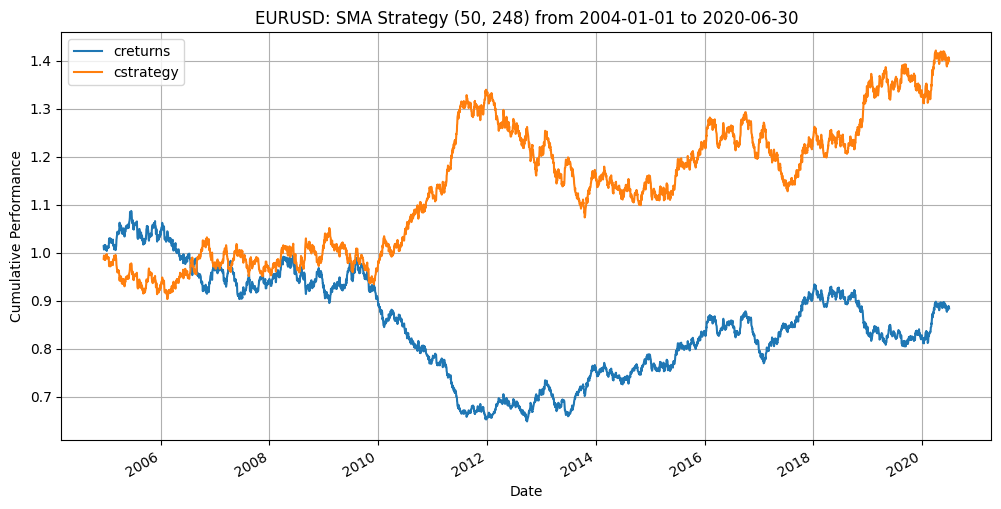

In [77]:
tester.plot_results()


This chart shows the cumulative performance of the best in-sample SMA strategy found by the brute-force search.


## 8. Inspect All Optimisation Results

The method also stores all tested combinations in `tester.optimization_results`. This is helpful because it lets us inspect not only the single best strategy, but the whole optimisation landscape.


In [78]:
tester.optimization_results.head()


,sma_short,sma_long,performance,outperformance
0,10,100,0.875942,0.024497
1,10,101,0.899757,0.046879
2,10,102,0.941965,0.094075
3,10,103,0.942571,0.093338
4,10,104,0.938684,0.092282


In [79]:
len(tester.optimization_results)


6191

In [80]:
tester.optimization_results.sort_values("performance", ascending=False).head(10)


,sma_short,sma_long,performance,outperformance
6188,50,248,1.398686,0.515191
4077,37,100,1.397791,0.546346
6189,50,249,1.395259,0.523255
6186,50,246,1.394649,0.508170
3775,35,100,1.392856,0.541410
6187,50,247,1.383800,0.492953
6185,50,245,1.379941,0.498565
3928,36,102,1.378207,0.530317
3927,36,101,1.373427,0.520549
6190,50,250,1.361505,0.484910


If many nearby parameter combinations perform similarly, the result may be more robust. If only one isolated combination performs well, that may be a warning sign of overfitting.


## 9. Optional Visualisation of the Optimisation Surface

We can also visualise the optimisation results as a heatmap-style chart. This helps us see whether the best result is part of a broader stable region or just a narrow spike.


In [81]:
pivot = tester.optimization_results.pivot(
    index="sma_short",
    columns="sma_long",
    values="performance"
)

pivot.head()


sma_long,100,101,102,103,104,105,106,107,108,109,...,241,242,243,244,245,246,247,248,249,250
sma_short,,,,,,,,,,,,,,,,,,,,,
10,0.875942,0.899757,0.941965,0.942571,0.938684,0.938584,0.946957,0.960011,0.972219,0.950470,...,1.037944,1.005512,1.009783,1.027076,1.047313,1.037082,0.999796,1.019181,1.032415,1.023714
11,0.898538,0.906202,0.960870,0.929174,0.969894,0.953793,0.954536,1.001250,0.967500,0.946677,...,1.072008,1.040077,1.017928,1.018035,1.053433,1.077663,1.045581,1.035857,1.046978,1.060748
12,0.903032,0.892091,0.897639,0.920015,0.939948,0.942106,0.959761,0.971080,0.931598,0.921703,...,1.060057,1.048780,1.041104,1.043496,1.025665,1.001377,0.999978,0.988358,1.001960,1.001123
13,0.981685,0.958003,0.975249,0.992899,1.032452,1.047120,1.006911,1.003559,0.951885,0.944460,...,1.027051,1.046341,1.049222,1.091069,1.113980,1.087228,1.023392,1.065846,1.080147,1.085405
14,1.020317,1.044017,1.041081,1.030196,1.021166,0.947101,0.890932,0.903196,0.899264,0.860671,...,1.074445,1.037835,1.011046,1.002141,1.012976,1.013841,1.006912,1.052463,1.090016,1.084306


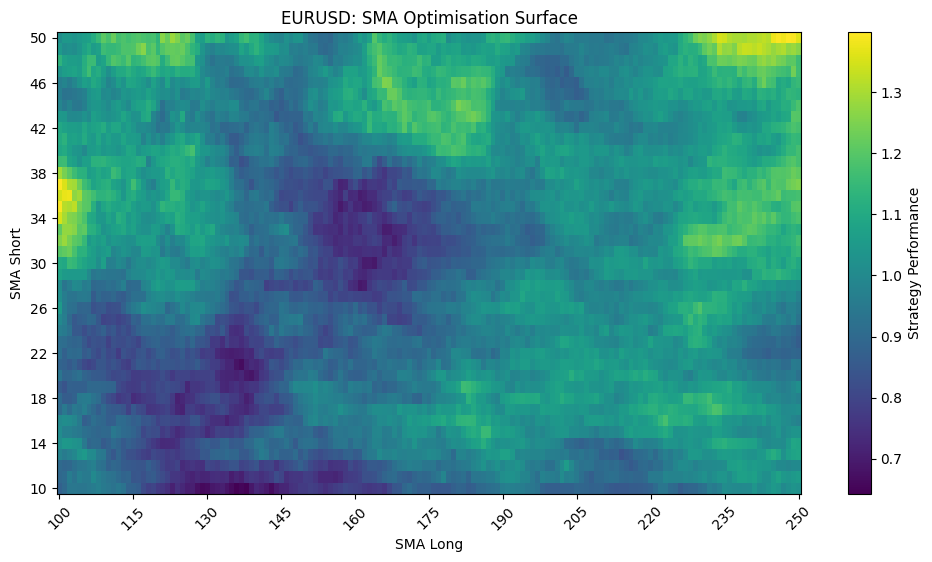

In [82]:
plt.figure(figsize=(12, 6))
plt.imshow(
    pivot,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="Strategy Performance")
plt.title(f"{tester.symbol}: SMA Optimisation Surface")
plt.xlabel("SMA Long")
plt.ylabel("SMA Short")

plt.xticks(
    ticks=range(0, len(pivot.columns), max(1, len(pivot.columns) // 10)),
    labels=pivot.columns[::max(1, len(pivot.columns) // 10)],
    rotation=45
)

plt.yticks(
    ticks=range(0, len(pivot.index), max(1, len(pivot.index) // 10)),
    labels=pivot.index[::max(1, len(pivot.index) // 10)]
)

plt.show()


The brighter or darker regions, depending on the default colour scale, show where performance was higher or lower. We should be cautious about choosing parameters from a very narrow isolated area.


## 10. Optimise Another Instrument

Now test the same optimisation process on another instrument. A strategy that performs well on one instrument may perform poorly or unreliably on another.


In [83]:
aud_tester = SMABacktester(
    symbol="AUDEUR",
    sma_short=50,
    sma_long=200,
    start="2004-01-01",
    end="2020-06-30"
)

aud_tester.test_strategy()


(np.float64(1.47657), np.float64(0.336975))

In [84]:
aud_best_params, aud_best_performance = aud_tester.optimize_parameters(
    sma_short_range=(10, 51, 1),
    sma_long_range=(100, 251, 1)
)

aud_best_params, aud_best_performance


((46, 189), 1.59374)

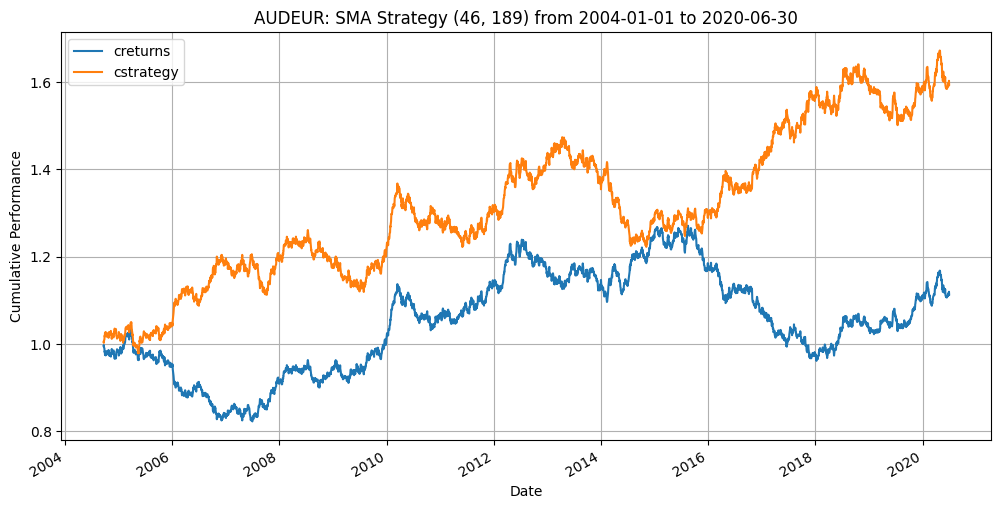

In [85]:
aud_tester.plot_results()


The goal is not only to find the highest number, but to check whether the strategy behaves consistently over time.


## 11. Overfitting Warning

**Optimisation is powerful, but dangerous.**

By testing thousands of combinations, we increase the chance of finding a parameter pair that worked well by luck on historical data. This is called **overfitting**.

The best in-sample strategy is not automatically the best future strategy. To make the analysis more realistic, the next step should be:

- optimise parameters on a training period
- test the selected parameters on a later unseen period
- compare in-sample and out-of-sample performance

That will be introduced in the next section.


## 12. Final Summary

- We added an `optimize_parameters()` method.
- The method uses `itertools.product()` to create all SMA parameter combinations.
- It loops through each combination.
- It updates the SMA settings using `set_parameters()`.
- It tests each strategy using `test_strategy()`.
- It stores all results in `self.optimization_results`.
- It finds the best-performing combination.
- It resets the object to the best SMA parameters.
- It runs the best strategy again so `self.results` matches the optimum.
- We can plot the optimised strategy immediately with `plot_results()`.
- Optimisation must be treated carefully because it can lead to overfitting.


# Building the SMABacktester Class from Scratch — Part 7: Separating `get_data()` and `prepare_data()`

The current version of the class works, but the design can be improved.

At the moment, `get_data()` loads the data and also calculates the SMA indicators. That is acceptable for a simple class, but it mixes two responsibilities:

- general data loading
- strategy-specific feature preparation

In a more flexible backtesting framework, these should be separated.

The general data-loading process is likely to be reused for many different strategies. For example, whether we are testing:

- an SMA crossover strategy
- a momentum strategy
- a mean-reversion strategy
- a breakout strategy

we still need to load prices, select a symbol, choose a time period, and calculate returns.

But the indicators are strategy-specific. For this SMA strategy, the specific indicators are:

- `sma_short`
- `sma_long`

So we will create a dedicated `prepare_data()` method for the SMA-specific part.


## 1. The Current Design Issue

In the previous class, the `get_data()` method looked after both the basic data workflow and the SMA-specific workflow.

```python
def get_data(self):
    # General workflow
    load CSV data
    select symbol
    select time period
    rename column to price
    calculate returns

    # Strategy-specific workflow
    calculate sma_short
    calculate sma_long
```

This works, but if we later wanted to create a different strategy, we would have to modify `get_data()`. A cleaner structure is:

```python
def get_data(self):
    # General workflow only
    load CSV data
    select symbol
    select time period
    rename column to price
    calculate returns

def prepare_data(self):
    # SMA-specific workflow only
    calculate sma_short
    calculate sma_long
```


## 2. Redefine the Class with `prepare_data()`

Now we redefine the class so that:

- `get_data()` only handles general data loading and returns
- `prepare_data()` adds the SMA columns
- `__init__()` calls both methods automatically

The order matters:

```python
self.get_data()
self.prepare_data()
```

We need the basic price and return data first. Then we can add the SMA columns.


In [86]:
from itertools import product

class SMABacktester:
    """
    A simple class blueprint for SMA crossover backtesting.

    This version can:
    - store backtest settings
    - load and prepare basic price data
    - add SMA-specific indicators in prepare_data()
    - update SMA parameters safely
    - test an SMA crossover strategy
    - plot strategy results
    - optimise SMA parameters
    """

    def __init__(self, symbol, sma_short, sma_long, start, end, data_path="forex_pairs.csv"):
        self.symbol = symbol
        self.sma_short = sma_short
        self.sma_long = sma_long
        self.start = start
        self.end = end
        self.data_path = data_path

        self.results = None
        self.data = None
        self.optimization_results = None

        # Step 1: load general price data and returns
        self.get_data()

        # Step 2: add strategy-specific indicators
        self.prepare_data()

    def __repr__(self):
        return (
            f"SMABacktester(symbol={self.symbol}, "
            f"sma_short={self.sma_short}, "
            f"sma_long={self.sma_long}, "
            f"start={self.start}, "
            f"end={self.end})"
        )

    def get_data(self):
        """
        Load price data and perform general preprocessing.

        This method is intentionally strategy-agnostic.
        It does not calculate SMA indicators.
        """

        df = pd.read_csv(
            self.data_path,
            parse_dates=["Date"],
            index_col="Date"
        )

        if self.symbol not in df.columns:
            raise ValueError(
                f"Symbol '{self.symbol}' not found in {self.data_path}. "
                f"Available symbols: {list(df.columns)}"
            )

        raw = df[[self.symbol]].dropna().copy()
        raw = raw.loc[self.start:self.end].copy()

        raw.rename(columns={self.symbol: "price"}, inplace=True)
        raw["returns"] = np.log(raw["price"] / raw["price"].shift(1))

        self.data = raw

        return raw

    def prepare_data(self):
        """
        Add SMA-specific indicators to the data.

        This method contains the strategy-specific preparation for
        the SMA crossover strategy.
        """

        data = self.data.copy()
        data["sma_short"] = data["price"].rolling(self.sma_short).mean()
        data["sma_long"] = data["price"].rolling(self.sma_long).mean()

        self.data = data

        # Any previous results no longer match the newly prepared data
        self.results = None

        return data

    def set_parameters(self, sma_short=None, sma_long=None):
        """
        Update SMA parameters and recalculate the strategy-specific data.
        """

        if sma_short is not None:
            self.sma_short = sma_short

        if sma_long is not None:
            self.sma_long = sma_long

        # Recalculate SMA columns using the updated parameters
        self.prepare_data()

        return self.data

    def test_strategy(self):
        """
        Backtest the SMA crossover strategy.

        Returns
        -------
        tuple
            Absolute strategy performance and outperformance versus buy and hold.
        """

        data = self.data.copy().dropna()

        # Generate trading positions:
        # long = 1 when short SMA is above long SMA
        # short = -1 otherwise
        data["position"] = np.where(data["sma_short"] > data["sma_long"], 1, -1)

        # Use yesterday's position for today's return to avoid look-ahead bias
        data["strategy"] = data["position"].shift(1) * data["returns"]

        data.dropna(inplace=True)

        # Cumulative buy-and-hold performance
        data["creturns"] = np.exp(data["returns"].cumsum())

        # Cumulative strategy performance
        data["cstrategy"] = np.exp(data["strategy"].cumsum())

        # Store full backtest result
        self.results = data

        absolute_performance = data["cstrategy"].iloc[-1]
        buy_and_hold_performance = data["creturns"].iloc[-1]
        outperformance = absolute_performance - buy_and_hold_performance

        return round(absolute_performance, 6), round(outperformance, 6)

    def plot_results(self):
        """
        Plot cumulative buy-and-hold performance and cumulative strategy performance.
        """

        if self.results is None:
            print("Run test_strategy() first.")
        else:
            title = (
                f"{self.symbol}: SMA Strategy "
                f"({self.sma_short}, {self.sma_long}) "
                f"from {self.start} to {self.end}"
            )

            self.results[["creturns", "cstrategy"]].plot(figsize=(12, 6))
            plt.title(title)
            plt.xlabel("Date")
            plt.ylabel("Cumulative Performance")
            plt.grid(True)
            plt.show()

    def optimize_parameters(self, sma_short_range, sma_long_range):
        """
        Brute-force optimisation of SMA parameters.

        Parameters
        ----------
        sma_short_range : tuple
            Tuple in the form (start, stop, step) for short SMA values.

        sma_long_range : tuple
            Tuple in the form (start, stop, step) for long SMA values.

        Returns
        -------
        tuple
            Best parameter combination and best strategy performance.
        """

        combinations = list(product(
            range(*sma_short_range),
            range(*sma_long_range)
        ))

        results = []

        for sma_short, sma_long in combinations:
            # A short SMA should be shorter than the long SMA
            if sma_short >= sma_long:
                continue

            self.set_parameters(sma_short=sma_short, sma_long=sma_long)
            performance, outperformance = self.test_strategy()

            results.append({
                "sma_short": sma_short,
                "sma_long": sma_long,
                "performance": performance,
                "outperformance": outperformance
            })

        self.optimization_results = pd.DataFrame(results)

        if self.optimization_results.empty:
            raise ValueError("No valid SMA combinations were tested. Check the parameter ranges.")

        best_row = self.optimization_results.loc[
            self.optimization_results["performance"].idxmax()
        ]

        best_sma_short = int(best_row["sma_short"])
        best_sma_long = int(best_row["sma_long"])
        best_performance = round(float(best_row["performance"]), 6)

        # Reset the object to the optimal parameters
        self.set_parameters(best_sma_short, best_sma_long)

        # Run the best strategy once more so self.results matches the optimum
        self.test_strategy()

        return (best_sma_short, best_sma_long), best_performance


## 3. Create an Object and Inspect the Data

When we create an object, the class now automatically runs:

```python
self.get_data()
self.prepare_data()
```

So `self.data` should contain both the general columns and the SMA-specific columns.


In [87]:
tester = SMABacktester(
    symbol="EURUSD",
    sma_short=50,
    sma_long=200,
    start="2004-01-01",
    end="2020-06-30"
)

tester


SMABacktester(symbol=EURUSD, sma_short=50, sma_long=200, start=2004-01-01, end=2020-06-30)

In [88]:
tester.data.head()


,price,returns,sma_short,sma_long
Date,,,,
2004-01-01,1.201671,NaN,NaN,NaN
2004-01-02,1.196084,-0.004660,NaN,NaN
2004-01-05,1.200154,0.003397,NaN,NaN
2004-01-06,1.205269,0.004253,NaN,NaN
2004-01-07,1.194757,-0.008760,NaN,NaN


In [89]:
tester.data.tail()


,price,returns,sma_short,sma_long
Date,,,,
2020-06-24,1.003797,-0.000827,1.006649,0.962648
2020-06-25,1.001816,-0.001975,1.006453,0.963056
2020-06-26,1.006790,0.004953,1.006395,0.963485
2020-06-29,1.003543,-0.003231,1.006228,0.963915
2020-06-30,1.000881,-0.002656,1.006174,0.964292


The DataFrame still contains:

- `price`
- `returns`
- `sma_short`
- `sma_long`

But now these columns were created in two separate stages:

- `get_data()` created `price` and `returns`
- `prepare_data()` created `sma_short` and `sma_long`


## 4. Confirm That `get_data()` Is Now Strategy-Agnostic

To confirm the separation, we can call `get_data()` on its own. This method should only create the basic price and return columns.


In [90]:
basic_data = tester.get_data()
basic_data.head()


,price,returns
Date,,
2004-01-01,1.201671,NaN
2004-01-02,1.196084,-0.004660
2004-01-05,1.200154,0.003397
2004-01-06,1.205269,0.004253
2004-01-07,1.194757,-0.008760


In [91]:
basic_data.columns


Index(['price', 'returns'], dtype='object')

At this stage, the data only has the general columns:

- `price`
- `returns`


In [92]:
prepared_data = tester.prepare_data()
prepared_data.head()


,price,returns,sma_short,sma_long
Date,,,,
2004-01-01,1.201671,NaN,NaN,NaN
2004-01-02,1.196084,-0.004660,NaN,NaN
2004-01-05,1.200154,0.003397,NaN,NaN
2004-01-06,1.205269,0.004253,NaN,NaN
2004-01-07,1.194757,-0.008760,NaN,NaN


In [93]:
prepared_data.columns


Index(['price', 'returns', 'sma_short', 'sma_long'], dtype='object')

After calling `prepare_data()`, the SMA-specific columns are added back:

- `sma_short`
- `sma_long`


## 5. Confirm the Strategy Still Works

This refactor should not change the external behaviour of the class. The strategy should still be testable in the same way as before.


In [94]:
tester.test_strategy()


(np.float64(0.945597), np.float64(0.091777))

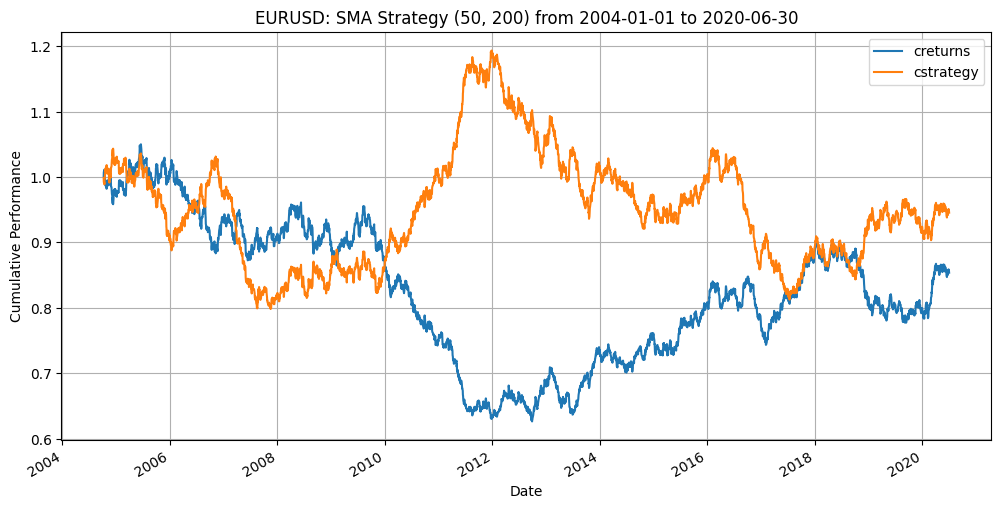

In [95]:
tester.plot_results()


The class now behaves the same from the user’s perspective, but the internal design is cleaner.


## 6. Confirm `set_parameters()` Still Works

The `set_parameters()` method is now simpler. Instead of recalculating each SMA column directly inside `set_parameters()`, it updates the attributes and then calls:

```python
self.prepare_data()
```

This keeps all strategy-specific preparation in one place.


In [96]:
tester.set_parameters(sma_short=75, sma_long=150)
tester.data[["sma_short", "sma_long"]].isna().sum()


sma_short     74
sma_long     149
dtype: int64

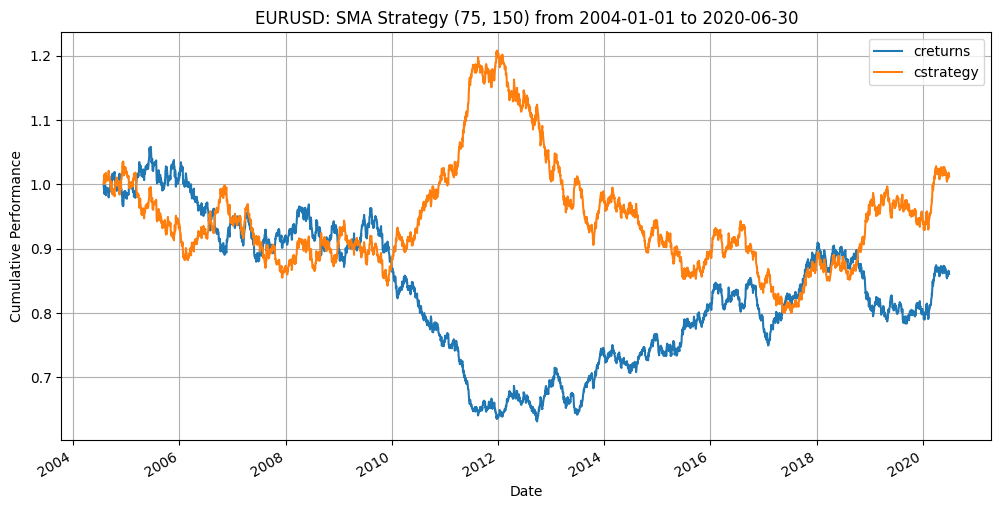

In [97]:
tester.test_strategy()
tester.plot_results()


The object successfully recalculates the SMA columns using the new parameters and then retests the strategy.


## 7. Confirm Optimisation Still Works

The optimisation method should also still work because it uses `set_parameters()`. Each time `set_parameters()` is called, the class automatically updates the SMA indicators through `prepare_data()`.


In [98]:
best_params, best_performance = tester.optimize_parameters(
    sma_short_range=(10, 31, 5),
    sma_long_range=(100, 201, 25)
)

best_params, best_performance


((30, 100), 1.103551)

In [99]:
tester.optimization_results.sort_values("performance", ascending=False).head()


,sma_short,sma_long,performance,outperformance
20,30,100,1.103551,0.252106
14,20,200,1.056498,0.202678
9,15,200,1.025256,0.171437
19,25,200,1.021120,0.167301
5,15,100,1.011174,0.159728


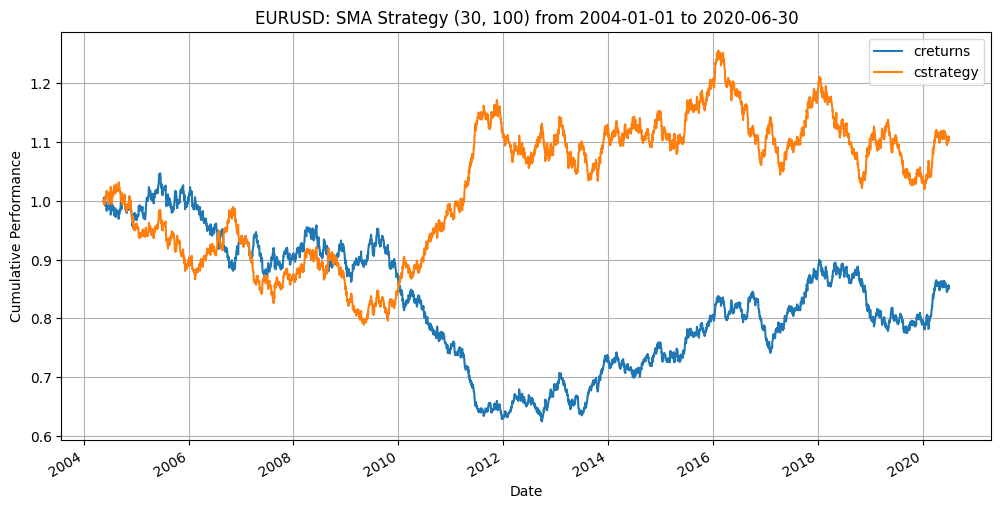

In [100]:
tester.plot_results()


The optimisation process still works after the refactor. The benefit is that if we later change the way SMA-specific data is prepared, we only need to update `prepare_data()`.


## 8. Why This Design Is Better

This refactor improves the reliability and maintainability of the class. The responsibilities are now clearer:

```python
get_data()
```

is responsible for general data loading and basic preprocessing.

```python
prepare_data()
```

is responsible for strategy-specific indicator calculation.

This is useful because many future strategies can reuse the same `get_data()` method. For example:

- an SMA strategy can define `prepare_data()` with moving averages
- a momentum strategy can define `prepare_data()` with rolling returns
- a mean-reversion strategy can define `prepare_data()` with z-scores
- a breakout strategy can define `prepare_data()` with rolling highs and lows

In each case, the basic data-loading workflow remains the same. Only the strategy-specific preparation changes.


## 9. Optional Mini-Example: Imagine a Different Strategy

For a momentum strategy, `prepare_data()` might look like:

```python
def prepare_data(self):
    data = self.data.copy()
    data["momentum"] = data["returns"].rolling(self.window).mean()
    self.data = data
```

For a mean-reversion strategy, it might look like:

```python
def prepare_data(self):
    data = self.data.copy()
    data["rolling_mean"] = data["price"].rolling(self.window).mean()
    data["rolling_std"] = data["price"].rolling(self.window).std()
    data["z_score"] = (data["price"] - data["rolling_mean"]) / data["rolling_std"]
    self.data = data
```

The point is that `get_data()` can stay the same while `prepare_data()` changes depending on the strategy.


## 10. Final Summary

- We improved the internal design of the `SMABacktester` class.
- `get_data()` now handles only general data loading and return calculation.
- `prepare_data()` now handles SMA-specific indicator calculation.
- `__init__()` calls both methods automatically.
- `set_parameters()` now updates the SMA attributes and calls `prepare_data()`.
- `test_strategy()`, `plot_results()`, and `optimize_parameters()` still work as before.
- This separation makes the class easier to maintain.
- It also makes the structure easier to reuse for more complex strategies later.


# Building the SMABacktester Class from Scratch — Part 8: Docstrings and String Representation

The class now works, but the user experience can still be improved.

If we display an object without a custom `__repr__()` method, Python may show a technical memory-style representation such as:

```python
<__main__.SMABacktester at 0x...>
```

This is not very useful.

We also want the methods to explain themselves when using help tools such as:

```python
help(SMABacktester)
help(tester.optimize_parameters)
```

or when using notebook tooltips. This is where docstrings are useful.

Docstrings are short descriptions written inside classes and methods. They explain what the class or method does, what parameters are expected, and what is returned.


## 1. The Usability Problem

Before improving the class, let’s remind ourselves why this matters. A class without a useful representation may not be very readable when displayed in a notebook.


In [ ]:
class MinimalBacktester:
    def __init__(self, symbol, sma_short, sma_long):
        self.symbol = symbol
        self.sma_short = sma_short
        self.sma_long = sma_long

minimal = MinimalBacktester("EURUSD", 50, 200)
minimal


The default output is technically correct, but it is not very informative.


In [ ]:
class MinimalBacktester:
    def __init__(self, symbol, sma_short, sma_long):
        self.symbol = symbol
        self.sma_short = sma_short
        self.sma_long = sma_long

    def __repr__(self):
        return (
            f"MinimalBacktester(symbol={self.symbol}, "
            f"sma_short={self.sma_short}, "
            f"sma_long={self.sma_long})"
        )

minimal = MinimalBacktester("EURUSD", 50, 200)
minimal


Now the object clearly tells us what it represents. We want the same improvement for our `SMABacktester`.


## 2. What Docstrings Do

A docstring is a string written directly inside a class or method. For example:

```python
def test_strategy(self):
    """
    Backtest the SMA crossover strategy.
    """
```

This text can be displayed by tools such as:

```python
help(tester.test_strategy)
```

Good docstrings are especially useful when a class has several methods and parameters. For this class, we will add docstrings to:

- the class itself
- `__init__`
- `__repr__`
- `get_data`
- `prepare_data`
- `set_parameters`
- `test_strategy`
- `plot_results`
- `optimize_parameters`


## 3. Redefine the Final Documented Class

Now we redefine the full class with clearer docstrings and a better string representation. The actual trading logic remains the same. We are only improving readability and usability.


In [ ]:
from itertools import product

class SMABacktester:
    """
    Class for the vectorized backtesting of SMA-based trading strategies.

    The class loads historical price data, calculates log returns,
    prepares simple moving average indicators, tests an SMA crossover
    strategy, plots cumulative performance, and can optimise SMA
    parameters by brute force.

    Parameters
    ----------
    symbol : str
        Ticker symbol or column name of the instrument to backtest.

    sma_short : int
        Window length, in trading days, for the shorter simple moving average.

    sma_long : int
        Window length, in trading days, for the longer simple moving average.

    start : str
        Start date for the backtest period. Expected format: "YYYY-MM-DD".

    end : str
        End date for the backtest period. Expected format: "YYYY-MM-DD".

    data_path : str, default "forex_pairs.csv"
        Path to the CSV file containing price data. The CSV should have a
        Date column and one column per instrument.
    """

    def __init__(self, symbol, sma_short, sma_long, start, end, data_path="forex_pairs.csv"):
        """
        Initialize a new SMABacktester object.

        Parameters
        ----------
        symbol : str
            Ticker symbol or column name of the instrument to backtest.

        sma_short : int
            Window length for the shorter SMA.

        sma_long : int
            Window length for the longer SMA.

        start : str
            Start date for the backtest period.

        end : str
            End date for the backtest period.

        data_path : str, default "forex_pairs.csv"
            Path to the CSV file containing the price data.
        """

        self.symbol = symbol
        self.sma_short = sma_short
        self.sma_long = sma_long
        self.start = start
        self.end = end
        self.data_path = data_path

        self.results = None
        self.data = None
        self.optimization_results = None

        self.get_data()
        self.prepare_data()

    def __repr__(self):
        """
        Return a readable string representation of the object.
        """

        return (
            f"SMABacktester object | symbol={self.symbol}, "
            f"sma_short={self.sma_short}, "
            f"sma_long={self.sma_long}, "
            f"start={self.start}, "
            f"end={self.end}"
        )

    def get_data(self):
        """
        Load price data and perform general preprocessing.

        This method loads the CSV file, selects the requested instrument,
        restricts the data to the selected date range, renames the price
        column to "price", and calculates log returns.

        This method is intentionally strategy-agnostic. It does not calculate
        SMA indicators.

        Returns
        -------
        pandas.DataFrame
            DataFrame containing price and log returns.
        """

        df = pd.read_csv(
            self.data_path,
            parse_dates=["Date"],
            index_col="Date"
        )

        if self.symbol not in df.columns:
            raise ValueError(
                f"Symbol '{self.symbol}' not found in {self.data_path}. "
                f"Available symbols: {list(df.columns)}"
            )

        raw = df[[self.symbol]].dropna().copy()
        raw = raw.loc[self.start:self.end].copy()

        raw.rename(columns={self.symbol: "price"}, inplace=True)
        raw["returns"] = np.log(raw["price"] / raw["price"].shift(1))

        self.data = raw

        return raw

    def prepare_data(self):
        """
        Prepare SMA-specific indicator data.

        This method adds the shorter and longer simple moving averages
        required for the SMA crossover strategy.

        Returns
        -------
        pandas.DataFrame
            DataFrame containing price, returns, sma_short, and sma_long.
        """

        data = self.data.copy()

        data["sma_short"] = data["price"].rolling(self.sma_short).mean()
        data["sma_long"] = data["price"].rolling(self.sma_long).mean()

        self.data = data
        self.results = None

        return data

    def set_parameters(self, sma_short=None, sma_long=None):
        """
        Update SMA parameters and refresh the prepared dataset.

        Parameters
        ----------
        sma_short : int or None, default None
            New short SMA window. If None, the existing value is kept.

        sma_long : int or None, default None
            New long SMA window. If None, the existing value is kept.

        Returns
        -------
        pandas.DataFrame
            Updated prepared dataset.
        """

        if sma_short is not None:
            self.sma_short = sma_short

        if sma_long is not None:
            self.sma_long = sma_long

        self.prepare_data()

        return self.data

    def test_strategy(self):
        """
        Backtest the SMA crossover strategy.

        The strategy goes long when the shorter SMA is above the longer SMA
        and short otherwise.

        Strategy returns are calculated using the previous day's position
        to avoid look-ahead bias.

        Returns
        -------
        tuple
            A tuple containing:

            - absolute strategy performance
            - outperformance compared to buy and hold
        """

        data = self.data.copy().dropna()

        data["position"] = np.where(data["sma_short"] > data["sma_long"], 1, -1)
        data["strategy"] = data["position"].shift(1) * data["returns"]

        data.dropna(inplace=True)

        data["creturns"] = np.exp(data["returns"].cumsum())
        data["cstrategy"] = np.exp(data["strategy"].cumsum())

        self.results = data

        absolute_performance = data["cstrategy"].iloc[-1]
        buy_and_hold_performance = data["creturns"].iloc[-1]
        outperformance = absolute_performance - buy_and_hold_performance

        return round(absolute_performance, 6), round(outperformance, 6)

    def plot_results(self):
        """
        Plot cumulative strategy performance against buy and hold.

        The method plots:

        - cumulative buy-and-hold performance
        - cumulative SMA strategy performance

        If the strategy has not been tested yet, the method prints a message
        asking the user to run test_strategy() first.
        """

        if self.results is None:
            print("Run test_strategy() first.")
        else:
            title = (
                f"{self.symbol}: SMA Strategy "
                f"({self.sma_short}, {self.sma_long}) "
                f"from {self.start} to {self.end}"
            )

            self.results[["creturns", "cstrategy"]].plot(figsize=(12, 6))
            plt.title(title)
            plt.xlabel("Date")
            plt.ylabel("Cumulative Performance")
            plt.grid(True)
            plt.show()

    def optimize_parameters(self, sma_short_range, sma_long_range):
        """
        Find the best-performing SMA parameter combination.

        This method performs a brute-force search over all combinations
        of short and long SMA windows within the given ranges.

        Parameters
        ----------
        sma_short_range : tuple
            Tuple in the form (start, stop, step) for short SMA values.

            Example:
            (10, 51, 1) tests short SMA values from 10 to 50.

        sma_long_range : tuple
            Tuple in the form (start, stop, step) for long SMA values.

            Example:
            (100, 251, 1) tests long SMA values from 100 to 250.

        Returns
        -------
        tuple
            A tuple containing:

            - best parameter combination as (best_sma_short, best_sma_long)
            - best absolute strategy performance

        Notes
        -----
        This is an in-sample optimisation and can lead to overfitting.
        The selected parameters should be tested on unseen out-of-sample data.
        """

        combinations = list(product(
            range(*sma_short_range),
            range(*sma_long_range)
        ))

        results = []

        for sma_short, sma_long in combinations:

            if sma_short >= sma_long:
                continue

            self.set_parameters(sma_short=sma_short, sma_long=sma_long)
            performance, outperformance = self.test_strategy()

            results.append({
                "sma_short": sma_short,
                "sma_long": sma_long,
                "performance": performance,
                "outperformance": outperformance
            })

        self.optimization_results = pd.DataFrame(results)

        if self.optimization_results.empty:
            raise ValueError("No valid SMA combinations were tested. Check the parameter ranges.")

        best_row = self.optimization_results.loc[
            self.optimization_results["performance"].idxmax()
        ]

        best_sma_short = int(best_row["sma_short"])
        best_sma_long = int(best_row["sma_long"])
        best_performance = round(float(best_row["performance"]), 6)

        self.set_parameters(best_sma_short, best_sma_long)
        self.test_strategy()

        return (best_sma_short, best_sma_long), best_performance


## 4. Create an Object and Check the New Representation

Now create a new object and display it directly.


In [ ]:
tester = SMABacktester(
    symbol="EURUSD",
    sma_short=50,
    sma_long=200,
    start="2004-01-01",
    end="2020-06-30"
)

tester


Instead of a technical memory address, the object now gives a useful summary of the strategy configuration. It tells us:

- the instrument
- the short SMA window
- the long SMA window
- the start date
- the end date


## 5. Use `help()` to Inspect the Class

The docstrings now make the class easier to understand.


In [ ]:
help(SMABacktester)


This displays the class-level docstring and the method documentation.


## 6. Inspect a Specific Method Docstring

We can also inspect a single method.


In [ ]:
help(tester.optimize_parameters)


This is especially useful for methods that require specific argument formats. For example, `optimize_parameters()` expects two tuples:

```python
sma_short_range=(10, 51, 1)
sma_long_range=(100, 251, 1)
```

Each tuple follows the format:

```python
(start, stop, step)
```


## 7. Confirm the Class Still Works

These changes are cosmetic, so the class should behave exactly the same as before.


In [ ]:
tester.test_strategy()


In [ ]:
tester.plot_results()


In [ ]:
best_params, best_performance = tester.optimize_parameters(
    sma_short_range=(10, 31, 5),
    sma_long_range=(100, 201, 25)
)

best_params, best_performance


In [ ]:
tester


After optimisation, the object representation now shows the updated best SMA parameters.


## 8. Why This Matters

Docstrings and readable object representations do not change the trading logic, but they improve the usability of the class.

This matters because a backtesting class may be used many times with different instruments, parameters, and time periods. Clear documentation helps:

- future you understand the code
- other users use the class correctly
- notebook tooltips become more useful
- mistakes are reduced when calling methods
- the class feels more professional and reusable


## 9. Final Summary

- We added clearer docstrings to the class and methods.
- We improved the `__repr__()` method.
- The object now displays a meaningful strategy summary.
- The docstrings explain the purpose of each method.
- `help()` can now show useful guidance.
- These improvements make the class easier to use and maintain.
- The trading logic did not change.
- The next step can be to use the completed class for in-sample and out-of-sample testing.
